In [1]:
# keep a record of the heat blob dynamics 
# and output the final classification of each blob as human or residual heat for each frame at the end
# also, keep a record of the postures
# output the final classification of posture in each image seq
    # -1: unknown or unlabeled; 
    # 0: absence; 
    # 1: presence, unclassified; 
    # 2: standing; 
    # 3: sitting by bed; 
    # 4: sitting on bed; 
    # 5: lying w/o cover; 
    # 6: lying with cover
import sys
from pathlib import Path
sys.path.insert(0, "/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/src")

import yaml
import json   
from organizer_module.postprocessor import PostProcessor
from dataset.dataset import ThermalDataset
from heatsource_detection_module.extract import HeatSourceDetector
from posture_detection_module.CNN_model import SimpleIRA_CNN
from posture_detection_module.utils import remap_labels_simple, inverse_remap_labels_simple, label_to_text_simple, ThermalInvariantPreprocessor
from organizer_module.track_kalman import Tracker
from data_visualization_module.plot import DataVisualizer
import torch
import cv2
from tqdm import tqdm
import numpy as np

dv = DataVisualizer()
data_name = "case_study_hall1"



In [2]:
# visualization, 
def visualize_frame(ira, blobs, posture_label, index, waittime = 1):
    # visualize the blobs and posture label on the ira_highres image, and save the image to disk
    thermal_prepared = dv._prepare_thermal_for_colormap(ira)
    ira_color = cv2.applyColorMap(thermal_prepared, cv2.COLORMAP_JET)
    # rescale the image to 5 times
    scale_factor = 10
    ira_color = cv2.resize(ira_color, (ira_color.shape[1] * scale_factor, ira_color.shape[0] * scale_factor), interpolation=cv2.INTER_NEAREST)

    corr = 0
    k = 0

    # plot the blobs on the image, use green circle for human and yellow circle for residual heat
    for blob in blobs:
        if blob.mean_temp is None or blob.centroid is None:
            continue
        color = (0, 255, 0) if blob.is_residual == False else (0, 255, 255)
        # cv2.circle(ira_color, (int(blob.centroid[1]), int(blob.centroid[0])), 10, color, 2)
        # mark the blob id on the image
        x_min, y_min, x_max, y_max = blob.get_state()
        cv2.putText(ira_color, f'ID: {blob.id_fixed}', (int(x_min*scale_factor), int(y_min*scale_factor)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
        cv2.putText(ira_color, f'corr: {blob.corr:.4f}; k: {blob.k:.4f}', (int(x_min*scale_factor), int((y_min+15)*scale_factor)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
        # draw bbox
        corr = blob.corr
        k = blob.k
        x_min = int(x_min * scale_factor)
        y_min = int(y_min * scale_factor)
        x_max = int(x_max * scale_factor)
        y_max = int(y_max * scale_factor)
        cv2.rectangle(ira_color, (x_min, y_min), (x_max, y_max), color, 2)

    cv2.putText(ira_color, f'Frame: {index}| Posture: {posture_label}|Corr: {corr:.3f}|K: {k:.3f}', (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

    cv2.imshow('ira', ira_color)
    key = cv2.waitKey(waittime)
    if key == ord('q'):
        cv2.destroyAllWindows()
        sys.exit(0)


In [3]:
# code for running pipeline with visualization, confusion visualizer
# Run entire pipeline
def test_postprocessor():
    # use a data entry as test: /Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/data/hall5
    # 1. load the dataset
    # dataset = ThermalDataset("/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/data/office1_0")
    dataset = ThermalDataset(f"/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/data/{data_name}", noCam = True)
    # 2. initialize our system's components ==================================
    #   2.1. heatsource detection module: load the module
    heat_detector = HeatSourceDetector()
    thermalinvariantpreprocessor = ThermalInvariantPreprocessor()
    #   2.1. posture detector module: load the model
    posture_detector_model = SimpleIRA_CNN()
    # load the pretrained weights for posture detection model
    posture_detector_model.load_state_dict(torch.load('/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/weights/all_current_data.pth'))
    #   2.2. kalman tracker module: load the module
    tracker = Tracker()
    #   2.4. postprocessor module: load the module
    postprocessor = PostProcessor()
    
    gt_result_lst = []

    print("dataset length: ", len(dataset))

    # 3. loop through each fraome
    for idx in range(0, len(dataset), 1):
        # if idx == 8720:
        #     waittime = 0
        label = dataset.annotations_expanded[idx]
        # if label == -1:
        #      continue
        gt_result_lst.append(label)
        ira_highres = dataset.get_ira_highres(idx)
        #   3.1. detect heat source
        thresh, mask = heat_detector.get_thresh_mask_otsu(ira_highres)
        # mask_processed = heat_detector.process_frame_mask(ira_highres, min_size=100)
        mask_individual = heat_detector.process_frame_connected_components(ira_highres, min_size=100)
        #   3.2. detect presence with kalman tracker
        tracker.update_blobs(mask_individual, ira_highres, heat_detector.get_unmasked_mean(ira_highres, mask), idx)
        postprocessor.get_blobs(tracker.blobs, idx)
        #   3.3. posture detection if kalman shows presence; record it in postprocessor
        hasHuman = False
        for blob in tracker.blobs:
            if blob.is_residual == False: # if it is classified as human
                hasHuman = True
        if hasHuman:
            # clip and normalize the ira_highres image, and convert to tensor before feeding into the posture detection model
            ira_highres = thermalinvariantpreprocessor(ira_highres)
            posture = posture_detector_model(torch.tensor(ira_highres, dtype=torch.float32).unsqueeze(0)) # add batch and channel dimension
            posture_label = torch.argmax(posture, dim=1).item()
            # print("DEBUG: posture label: ", posture_label)
            posture_label = inverse_remap_labels_simple(posture_label)  # remap the posture label
            # print("DEBUG: inverse remap posture label: ", posture_label)
            postprocessor.get_posture(posture_label, idx)  # inverse remap the posture label
            posture_str = label_to_text_simple(posture_label)
        else:
            posture_label = 0
            posture_str = label_to_text_simple(posture_label)
            postprocessor.get_posture(0, idx)
        
    
    print("DEBUG: posture records: ", len(postprocessor.posture_records), len(gt_result_lst))

    with open(f'/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/output/{data_name}.json', 'w') as f:
        json.dump({'results': results, 'gt_result_lst': gt_result_lst}, f, indent=4)

    # 4. postprocess
    #   4.1. postprocess presence, make a list of presence data
    # postprocessor.postprocess_presence()

    #   4.2. postprocess postures, make a list of posture data.
    # postprocessor.postprocess_posture()

    # 5. compare the smoothed posture classification result with the ground truth label, and visualize the comparison
    # 5. visualize: plot the posture classification result for each frame, and compare with the ground truth label
    #   5.1. visualize the presence detection result for each frame, and compare with the ground truth label
    #   5.2. visualize the blob classification result for each frame, and compare with the ground truth label
   


def confusion_matrix_draw(results, gt_result_lst):
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    import matplotlib.pyplot as plt

    y_true = gt_result_lst
    y_pred = [1 if r[1] == 'HUMAN' else 0 for r in results]

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Human', 'Human'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix for Posture Classification")
    plt.show()


In [4]:
# run the entire pipeline on one data entry with visualizer
def test_inference(data_name=data_name, model_path = '/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/weights/all_current_data.pth', tag = "", k = None, corr = None, start_idx = 0):
    # use a data entry as test: /Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/data/hall5
    
    # 1. load the dataset ===============================================
    # dataset = ThermalDataset("/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/data/office1_0")
    dataset = ThermalDataset(f"/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/data/{data_name}", noCam = True)
    print(f"dataset {data_name}; length:", len(dataset))


    # 2. initialize our system's components ==================================
    #   2.1. heatsource detection module: load the module
    heat_detector = HeatSourceDetector()
    thermalinvariantpreprocessor = ThermalInvariantPreprocessor()
    #   2.1. posture detector module: load the model
    posture_detector_model = SimpleIRA_CNN()
    # load the pretrained weights for posture detection model
    posture_detector_model.load_state_dict(torch.load('/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/weights/all_current_data.pth'))
    #   2.2. kalman tracker module: load the module
    if k is not None:
        tracker = Tracker(k_thresh = k, temp_decrease_thresh = corr)
    else:
        tracker = Tracker()
    #   2.4. postprocessor module: load the module
    postprocessor = PostProcessor()

    import matplotlib.pyplot as plt
    from tqdm import tqdm
    

    # 3. loop through each fraome ========================================
    #   3.1. prepare the ground truth label list
    gt_result_lst = []
    waittime = 1
    visualization = True
    for idx in tqdm(range(start_idx, len(dataset), 1)):
        # gt
        label = dataset.annotations_expanded[idx]
        gt_result_lst.append(label)

        # data
        ira_highres = dataset.get_ira_highres(idx)
        # make pixels less than 17 deg be 17 deg
        ira_highres[ira_highres < 18] = 18

        # plt.imshow(ira_highres)
        # plt.show()

        #   3.1. detect heat source
        thresh, mask = heat_detector.get_thresh_mask_otsu(ira_highres)
        
        mask_individual = heat_detector.process_frame_connected_components(ira_highres, min_size=100)

        #   3.2. detect presence with kalman tracker
        tracker.update_blobs(mask_individual, ira_highres, heat_detector.get_unmasked_mean(ira_highres, mask), idx)
        postprocessor.get_blobs(tracker.blobs, idx)

        #   3.3. posture detection if kalman shows presence; record it in postprocessor
        hasHuman = False
        for blob in tracker.blobs:
            if blob.is_residual == False: # if it is classified as human
                hasHuman = True

        if hasHuman:
            # clip and normalize the ira_highres image, and convert to tensor before feeding into the posture detection model
            ira_highres = thermalinvariantpreprocessor(ira_highres)
            posture = posture_detector_model(torch.tensor(ira_highres, dtype=torch.float32).unsqueeze(0)) # add batch and channel dimension
            posture_label = torch.argmax(posture, dim=1).item()
            # print("DEBUG: posture label: ", posture_label)
            posture_label = inverse_remap_labels_simple(posture_label)  # remap the posture label
            # print("DEBUG: inverse remap posture label: ", posture_label)
            postprocessor.get_posture(posture_label, idx)  # inverse remap the posture label
            posture_str = label_to_text_simple(posture_label)
        else:
            posture_label = 0
            posture_str = label_to_text_simple(posture_label)
            postprocessor.get_posture(0, idx)

        # visualize the result for this frame
        if visualization:
            visualize_frame(ira_highres, tracker.blobs, posture_str, idx, 10)
    
    # 4. save the results to /Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/output/{data_name}.json
    with open(f'/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/output/previous/{data_name}_{tag}.json', 'w') as f:
        json.dump({'results': postprocessor.posture_records, 'gt_result_lst': gt_result_lst}, f, indent=4)

    # draw the confusion matrix for posture classificatino result
    # confusion_matrix_draw(postprocessor.posture_records, gt_result_lst)

def confusion_matrix_draw(results, gt_result_lst):
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

    y_true = gt_result_lst
    y_pred = [1 if r[1] == 'HUMAN' else 0 for r in results]

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Human', 'Human'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix for Posture Classification")
    plt.show()

# results = postprocessor.posture_records
# # write results and gt_result_lst to a json file for later analysis
# with open(f'/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/output/{data_name}.json', 'w') as f:
#     json.dump({'results': results, 'gt_result_lst': gt_result_lst}, f, indent=4)

def pipeline_gridsearch():
    # load yaml content from /Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/config/exp_setup.yaml
    with open('/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/config/exp_setup.yaml', 'r') as f:
        config = yaml.safe_load(f)
        train_all = config['train_all'][:3]
    TEMP_DECREASE_THRESH = [-0.9, -0.92, -0.95]
    K_THRESH = [0.003, 0.004, 0.005]

    for temp_thresh in TEMP_DECREASE_THRESH:
        for k_thresh in K_THRESH:
            pred = []
            gt = []
            print(f"Testing with TEMP_DECREASE_THRESH: {temp_thresh}, K_THRESH: {k_thresh}")
            for folder in train_all:
                gt_result_lst, pred_res_lst = pipeline_gridsearch(folder)
                pred.extend(pred_res_lst)
                gt.extend(gt_result_lst)
                print("accuracy: ", sum([1 if p == 1 and g == 1 else 0 for p, g in zip(pred_res_lst, gt_result_lst)]) / len(gt_result_lst))
                print("present predicted as absent: ", sum([1 if p == 0 and g == 1 else 0 for p, g in zip(pred_res_lst, gt_result_lst)]) / len(gt_result_lst))
                plt.plot(pred_res_lst, alpha = 0.5, label = "pred")
                plt.plot(gt_result_lst, alpha = 0.5, label = "GT")
                plt.legend()
                plt.show()
                print("absent predicted as present: ", sum([1 if p == 1 and g == 0 else 0 for p, g in zip(pred_res_lst, gt_result_lst)]) / len(gt_result_lst)) 
            print("===summary: present predicted as absent: ", sum([1 if p == 0 and g == 1 else 0 for p, g in zip(pred, gt)]) / len(gt))
            print("===summary: absent predicted as present: ", sum([1 if p == 1 and g == 0 else 0 for p, g in zip(pred, gt)]) / len(gt))
            print("=== summary: accuracy: ", sum([1 if p == 1 and g == 1 else 0 for p, g in zip(pred, gt)]) / len(gt)) 


def vis_json_results(data_name = data_name, suffix = "nopostprocess_exp"):
    import matplotlib.pyplot as plt
    from organizer_module.postprocessor import PostProcessor
    import numpy as np

    # load from json
    with open(f'/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/output/previous/{data_name}_{suffix}.json', 'r') as f:
        data = json.load(f)
        results = data['results']
        gt_result_lst = data['gt_result_lst']

    print("DEBUG: results len: ", len(results))
    print("DEBUG: gt_result_lst len: ", len(gt_result_lst))

    # Apply Markov smoothing to the results
    # pp = PostProcessor()
    # pp.posture_records = results.copy()
    # # pp._markov_smoothing()
    # smoothed_results = pp.posture_records

    smoothed_results = results.copy()

    def compute_accuracy_presence(pred, gt):
        correct = 0
        total = 0
        for i in range(len(gt)):
            g = gt[i]
            p = pred[i]
            if g == -1:
                # do nothing
                continue
            elif g==0 and p == 0:
                correct += 1
            elif g in [1, 2, 3, 4, 5, 6]:
                if p in [2, 3, 4, 5, 6]:
                    correct += 1
            total += 1
        return correct / total

    def compute_accuracy(pred, gt):
        correct = 0
        total = 0
        for i in range(len(gt)):
            g = gt[i]
            p = pred[i]
            if g == -1:
                # do nothing
                continue
            elif g == 1:
                if p in [2, 3, 4, 5, 6]:
                    correct += 1
            elif p == g:
                    correct += 1
            total += 1
        return correct / total
    
    def compute_recall(pred, gt):
        # compute recall for each class
        recall_dict = {}
        for cls in [0, 2, 3, 4, 5, 6]:
            tp = sum([1 if p == cls and g == cls else 0 for p, g in zip(pred, gt)])
            fn = sum([1 if p != cls and g == cls else 0 for p, g in zip(pred, gt)])
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            recall_dict[cls] = recall
        return recall_dict
    
    def compute_precision(pred, gt):
        # compute precision for each class
        precision_dict = {}
        for cls in [0, 2, 3, 4, 5, 6]:
            tp = sum([1 if p == cls and g == cls else 0 for p, g in zip(pred, gt)])
            fp = sum([1 if p == cls and g != cls else 0 for p, g in zip(pred, gt)])
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            precision_dict[cls] = precision
        return precision_dict
    
    def compute_f1(pred, gt):
        recall_dict = compute_recall(pred, gt)
        precision_dict = compute_precision(pred, gt)
        f1_dict = {}
        for cls in [0, 2, 3, 4, 5, 6]:
            precision = precision_dict[cls]
            recall = recall_dict[cls]
            f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
            f1_dict[cls] = f1
        return f1_dict

    accuracy_before = compute_accuracy(results, gt_result_lst)
    recall_before = compute_recall(results, gt_result_lst)
    precision_before = compute_precision(results, gt_result_lst)
    f1_before = compute_f1(results, gt_result_lst)
    # accuracy_after = compute_accuracy(smoothed_results, gt_result_lst)
    print("accuracy of presence: ", compute_accuracy_presence(results, gt_result_lst))
    print("accuracy of all poses: ", accuracy_before)
    
    print("recall of all poses: ", recall_before)

    plt.plot(smoothed_results, alpha = 0.5)
    # plt.plot(results, alpha = 0.5)
    plt.plot(gt_result_lst, alpha = 0.5)
    plt.show()
    # print(f"Accuracy before smoothing: {accuracy_before:.4f}")
    # print(f"Accuracy after smoothing: {accuracy_after:.4f}")

    # count the accuracy
    # when gt_results_lst is -1, we regard it as 0
    # when gt_results_lst is 1, it can match all the presence labels (2, 3, 4, 5, 6)
    # compute the accuracy
    correct = 0
    total = 0
    for i in range(len(gt_result_lst)):
        gt = gt_result_lst[i]
        pred = results[i]
        if gt == -1:
            gt = 0
        if gt == 1:
            if pred in [2, 3, 4, 5, 6]:
                correct += 1
        else:
            if pred == gt:
                correct += 1
        total += 1
    accuracy = correct / total
    print(f"Posture accuracy: {accuracy:.4f}")

    # results = [5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 2, 2]
    # exit prediction
    for i in range(10,len(results)-10):
        # if last 10 frames only have values within [3, 4, 5, 6]
        no2inPrev = True
        for idx in results[i-10:i]:
            if idx == 2:
                # print("found 2")
                no2inPrev = False
                break 
        
        if results[i] == 2 and no2inPrev:
            print(f"Exit predicted at frame {i} Pred: {results[i-1]} -> {results[i]})")
            
        # if gt_result_lst[i-1] in [0, 1] and gt_result_lst[i] in [2, 3, 4, 5, 6]:
        #     print(f"Entry predicted at frame {i} (GT: {gt_result_lst[i-1]} -> {gt_result_lst[i]}, Pred: {results[i-1]} -> {results[i]})")

    # plot confusion matrix
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    # presence classification confusion matrix
    y_true = [1 if r in [2, 3, 4, 5, 6] else 0 for r in gt_result_lst]
    y_pred = [1 if r in [2, 3, 4, 5, 6] else 0 for r in results]
    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix for Presence Classification:", cm)

    # disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Human', 'Human'])
    # disp.plot(cmap=plt.cm.Blues)
    # plt.title("Confusion Matrix for Presence Classification (Binary)")
    # plt.show()

    # plot posture classification confusion matrix
    # remove ambiguous labels in gt_result_lst and results
    y_true = [r for r in gt_result_lst if r != -1 and r != 1]
    y_pred = [results[i] for i in range(len(results)) if gt_result_lst[i] != -1 and gt_result_lst[i] != 1]
    cm = confusion_matrix(y_true, y_pred, labels=[0, 2, 3, 4, 5, 6])
    print("Confusion Matrix for Posture Classification (Detailed):", cm)

    # disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Human', 'Standing', 'Sitting by Bed', 'Sitting on Bed', 'Lying w/o Cover', 'Lying with Cover'])
    # disp.plot(cmap=plt.cm.Blues)
    # # rotate x label by 45 degree
    # plt.xticks(rotation=45)
    # plt.title("Confusion Matrix for Posture Classification (Detailed)")
    # plt.show()
def vis_results(data_name = "office0_4", tag = ""):
    # visualize the results in /Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/output/{data_name}_nopostprocess_exp.json
    # data_name = "home01"
    vis_json_results(data_name, tag)

def test_users_inenv():
    # test the model across different users
    model_path = "/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/weights/posture_cnn_all_full.pth"
    test_env = ['office0_4', 'home01', 'home2', 'home31']
    test_env = ['office0_4']

    # load the model
    for e in test_env:
        test_inference(model_path = model_path, data_name = e)

def test_users_crossenv():
    # test the model across different users and environments
    test_env = ['hall5', 'office1_0', 'office2_0']
    test_env_ids = ['env0', 'env5', 'env6']
    for env, env_id in zip(test_env, test_env_ids):
        model_path = f"/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/weights/posture_cnn_{env_id}.pth"
        test_inference(model_path = model_path, data_name = env)




1. lcx: pred: 1852; actual: [1843, 1854], 3 mispred
2. sf: pred: 2125; actual: [[2121, 2128]], 2 mispred
3. office0_4: Pred: 2452, [[2444, 2454], 5392, [5386, 5395]]; 3 mispred
4. office0_4_unlabeled: pred: 8514; [8511, 8517]; 11233: [11230, 11238], 6 mispred
5. office0_2: ;3 mispred; [3036, [3027, 3033], 7719, [7708, 7720], 14711, [14707, 14716]]: 
6. hall5: 1900: [1887, 1903], 2 false

In [5]:
# counting latency of bed exit prediction
data = [[1852, 1843], [2125, 2121], [2452, 2444], [5392, 5386], [8514, 8511], [11233, 11230], [3036, 3027], [7719, 7708], [14711, 14707], [1900, 1887]]

print(len(data))
diff = (a-b for a, b in data)
diff = np.average(list(diff))
print(diff)



10
7.0


213146


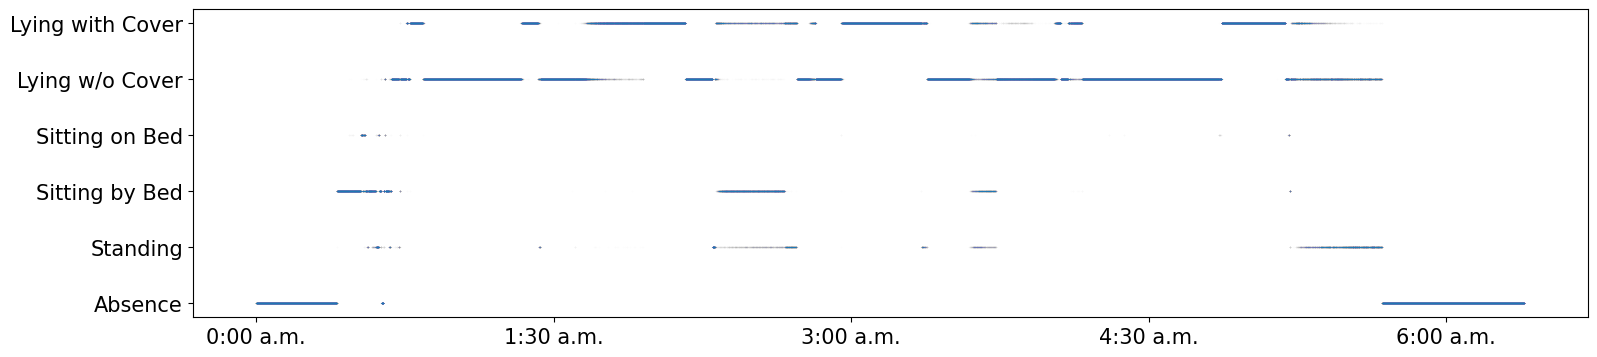

In [6]:
# case study
# test_results()
# test_postprocessor()

if __name__ == "__main__":
    # office0_4: 0.9919028340080972 len 12274
    # hall5: 0.9850 len 2394
    # office0_1: 0.9964912280701754, len 2963
    # office0_2: 0.9953646275380297, len 15525
    # office1_0: 0.9964, len 5433
    # office2_0: 0.9913, len 6004
    # home01: 
    env = "sleep_casestudy"
    model = "posture_cnn_cross_user_user5"
    tag = "case"
    # tag = "nopostprocess_exp"
    k = 0.005
    corr = -0.75
    # test_inference(env, model_path=f'/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/weights/weights/posture_cnn_cross_casestudy_0419.pth', tag = tag, k = k, corr = corr, start_idx = 5000)
    # vis_results(env, tag)
    # load json file: /Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/output/previous/sleep_casestudy_case.json
    filepath = f'/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/output/previous/{env}_{tag}.json'
    with open(filepath, 'r') as f:
        data = json.load(f)
        results = data['results']
    print(len(results))

    import matplotlib.pyplot as plt
    plt.figure(figsize=(18, 4))
    # plot: instead of connecting adjacent time points with lines
    # we only plot points w/o lines
    # y labels: 0: absence; 1: presence, unclassified; 2: standing; 3: sitting by bed; 4: sitting on bed; 5: lying w/o cover; 6: lying with cover
    
    # there is no "2" in label, remove it from the dataset entirely
    for i in range(len(results)):
        if results[i] >= 2:
            results[i] = results[i] - 1
    
    plt.scatter(range(len(results)), results, alpha = 0.002, s = 0.5)
    # set text size
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.yticks([0, 1, 2, 3, 4, 5], ['Absence', 'Standing', 'Sitting by Bed', 'Sitting on Bed', 'Lying w/o Cover', 'Lying with Cover'])
    plt.xticks(range(0, len(results), 50000), ['0:00 a.m.', '1:30 a.m.', '3:00 a.m.', '4:30 a.m.', '6:00 a.m.'])
    # count the number of 1, 2 between 25000 and 180000
    # plt.xticks(range(0, len(results), 10000))
    # count_1 = sum([1 for i in range(25000, 180000) if results[i] == 1])
    # count_2 = sum([1 for i in range(25000, 180000) if results[i] == 2])
    # count_3 = sum([1 for i in range(175000, 190000) if results[i] == 5])
    # count_4 = sum([1 for i in range(55000, 70000) if results[i] == 4])
    # count_5 = sum([1 for i in range(125000, 135000) if results[i] == 5])
    # print(f"total correct counts: {1-(count_1 + count_2 + count_3 + count_4 + count_5)/len(results)}")
    plt.savefig("sleep_casestudy_case.png", dpi=300)

In [ ]:
# test_results()
# test_postprocessor()
if __name__ == "__main__":
    # office0_4: 0.9919028340080972 len 12274
    # hall5: 0.9850 len 2394
    # office0_1: 0.9964912280701754, len 2963
    # office0_2: 0.9953646275380297, len 15525
    # office1_0: 0.9964, len 5433
    # office2_0: 0.9913, len 6004
    # home01: 
    env = "office0_sf_0"
    model = "posture_cnn_cross_user_user5"
    tag = "cross_user"
    # tag = "nopostprocess_exp"
    k = 0.005
    corr = -0.75
    test_inference(env, model_path=f'/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/weights/weights_final/{model}_0417.pth', tag = 'cross_user', k = k, corr = corr)
    vis_results(env, tag)
    # pipeline_gridsearch()
    # test_users_inenv()
    # test_users_crossenv()
    # saved here: /Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/output/previous/office0_sf_0_cross_user.json

dataset office0_sf_0; length: 2691


  0%|          | 0/2691 [00:00<?, ?it/s]

 31%|███       | 830/2691 [00:18<00:41, 45.13it/s]


AttributeError: 'Tracker' object has no attribute 'TEMP_DIFF_THRESH'

: 

# Cross user study: SF

DEBUG: results len:  2691
DEBUG: gt_result_lst len:  2691
accuracy of presence:  0.993633107839236
accuracy of all poses:  0.9928372463191405
recall of all poses:  {0: 0.9965457685664939, 2: 0.9488636363636364, 3: 1.0, 4: 0.9957894736842106, 5: 1.0, 6: 1.0}


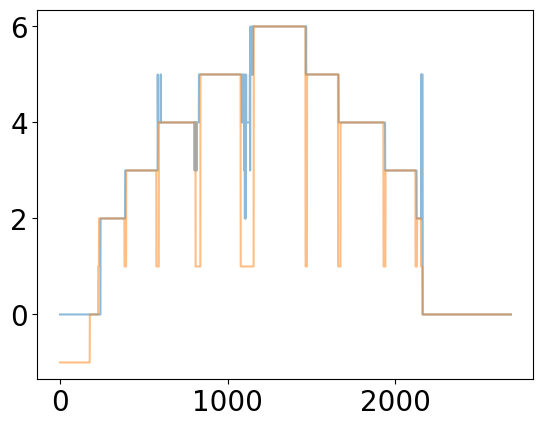

Posture accuracy: 0.9933
Exit predicted at frame 242 Pred: 0 -> 2)
Exit predicted at frame 1103 Pred: 4 -> 2)
Exit predicted at frame 2128 Pred: 3 -> 2)
Confusion Matrix for Presence Classification: [[ 760  187]
 [   9 1735]]
Confusion Matrix for Posture Classification (Detailed): [[577   0   0   0   2   0]
 [  9 167   0   0   0   0]
 [  0   0 359   0   0   0]
 [  0   0   1 473   1   0]
 [  0   0   0   0 425   0]
 [  0   0   0   0   0 309]]


In [ ]:
# test_results()
# test_postprocessor()
if __name__ == "__main__":
    # office0_4: 0.9919028340080972 len 12274
    # hall5: 0.9850 len 2394
    # office0_1: 0.9964912280701754, len 2963
    # office0_2: 0.9953646275380297, len 15525
    # office1_0: 0.9964, len 5433
    # office2_0: 0.9913, len 6004
    # home01: 
    env = "office0_sf_0"
    model = "posture_cnn_cross_user_user5"
    tag = "cross_user"
    # tag = "nopostprocess_exp"
    k = 0.005
    corr = -0.75
    # test_inference(env, model_path=f'/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/weights/weights_final/{model}_0417.pth', tag = 'cross_user', k = k, corr = corr)
    vis_results(env, tag)
    # pipeline_gridsearch()
    # test_users_inenv()
    # test_users_crossenv()
    # saved here: /Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/output/previous/office0_sf_0_cross_user.json

DEBUG: results len:  2506
DEBUG: gt_result_lst len:  2506
accuracy of presence:  0.9569672131147541
accuracy of all poses:  0.8922131147540984
recall of all poses:  {0: 0.8670360110803325, 2: 0.9823008849557522, 3: 1.0, 4: 0.5661971830985916, 5: 0.988795518207283, 6: 1.0}


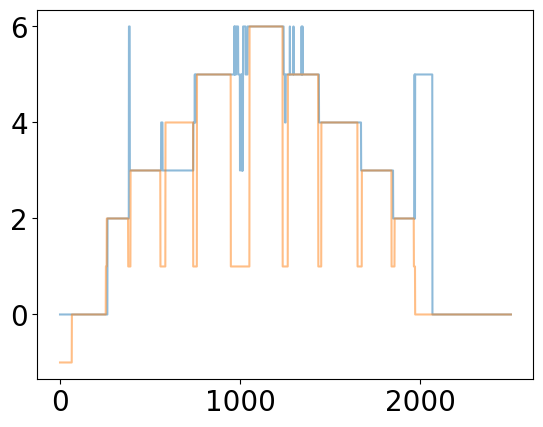

Accuracy: 0.8951
Exit predicted at frame 264 Pred: 0 -> 2)
Exit predicted at frame 1851 Pred: 3 -> 2)
Confusion Matrix for Presence Classification: [[ 697  356]
 [   4 1449]]
Confusion Matrix for Posture Classification (Detailed): [[626   0   0   0  96   0]
 [  4 222   0   0   0   0]
 [  0   0 331   0   0   0]
 [  0   0 154 201   0   0]
 [  0   0   0   0 353   4]
 [  0   0   0   0   0 184]]


In [12]:
# Cross User Study: lcx
if __name__ == "__main__":
    # office0_4: 0.9919028340080972 len 12274
    # hall5: 0.9850 len 2394
    # office0_1: 0.9964912280701754, len 2963
    # office0_2: 0.9953646275380297, len 15525
    # office1_0: 0.9964, len 5433
    # office2_0: 0.9913, len 6004
    # home01: 
    env = "office0_lcx_1"
    model = "posture_cnn_cross_user_user4"
    tag = "cross_user"
    k = 0.005
    corr = -0.75
    # test_inference(env, model_path=f'/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/weights/weights_final/{model}_0417.pth', tag = 'cross_user', k = k, corr = corr)
    vis_results(env, tag)
    # saved here: /Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/output/previous/office0_lcx_1_cross_user.json

dataset hall5; length: 2394


 80%|████████  | 1917/2394 [00:38<00:09, 50.42it/s]

Human left the bed! Residual heat detected. Frame index:  1909


100%|██████████| 2394/2394 [00:46<00:00, 51.39it/s]


DEBUG: results len:  2394
DEBUG: gt_result_lst len:  2394
accuracy of presence:  0.987881320518178
accuracy of all poses:  0.987881320518178
recall of all poses:  {0: 0.9708171206225681, 2: 0.9369369369369369, 3: 1.0, 4: 1.0, 5: 1.0, 6: 1.0}


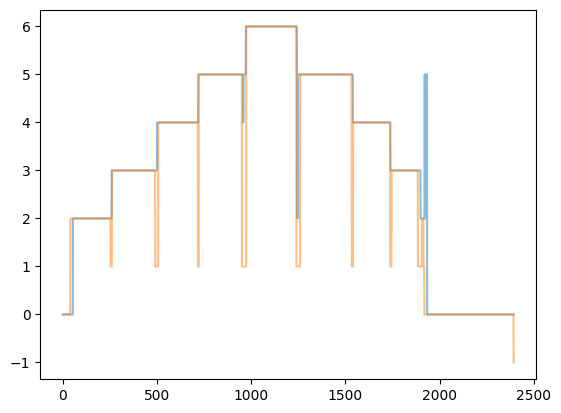

Accuracy: 0.9879
Exit predicted at frame 54 Pred: 0 -> 2)
Exit predicted at frame 1246 Pred: 5 -> 2)
Exit predicted at frame 1899 Pred: 3 -> 2)
Confusion Matrix for Presence Classification: [[ 500  125]
 [  14 1755]]
Confusion Matrix for Posture Classification (Detailed): [[499   4   0   0  11   0]
 [ 14 208   0   0   0   0]
 [  0   0 370   0   0   0]
 [  0   0   0 408   0   0]
 [  0   0   0   0 503   0]
 [  0   0   0   0   0 266]]


In [51]:
# Cross env 1
if __name__ == "__main__":
    # office0_4: 0.9919028340080972 len 12274
    # hall5: 0.9850 len 2394
    # office0_1: 0.9964912280701754, len 2963
    # office0_2: 0.9953646275380297, len 15525
    # office1_0: 0.9964, len 5433
    # office2_0: 0.9913, len 6004
    # home01: 
    env = "hall5"
    model = "posture_cnn_cross_env_env0"
    tag = "cross_env"
    # tag = "nopostprocess_exp"
    k = 0.005
    corr = -0.75
    test_inference(env, model_path=f'/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/weights/weights_final/{model}_0417.pth', tag = tag, k = k, corr = corr)
    vis_results(env, tag)

dataset office1_0; length: 6186


 88%|████████▊ | 5434/6186 [01:42<00:14, 51.69it/s]

Human left the bed! Residual heat detected. Frame index:  5426


100%|██████████| 6186/6186 [01:54<00:00, 53.89it/s]


DEBUG: results len:  6186
DEBUG: gt_result_lst len:  6186
accuracy of presence:  0.9954977488744372
accuracy of all poses:  0.9951642487910622
recall of all poses:  {0: 0.9873817034700315, 2: 1.0, 3: 0.9983221476510067, 4: 0.9991015274034142, 5: 1.0, 6: 1.0}


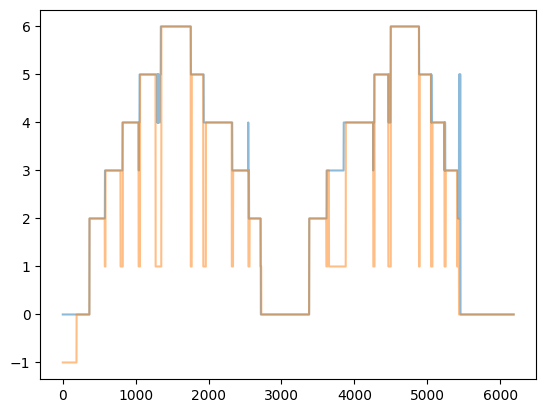

Accuracy: 0.9953
Exit predicted at frame 366 Pred: 0 -> 2)
Exit predicted at frame 2553 Pred: 3 -> 2)
Exit predicted at frame 3380 Pred: 0 -> 2)
Exit predicted at frame 5419 Pred: 3 -> 2)
Exit predicted at frame 5447 Pred: 5 -> 2)
Confusion Matrix for Presence Classification: [[1761  610]
 [   0 3815]]
Confusion Matrix for Posture Classification (Detailed): [[1565    1    0    0   19    0]
 [   0  603    0    0    0    0]
 [   0    0  595    1    0    0]
 [   0    0    1 1112    0    0]
 [   0    0    0    0  714    0]
 [   0    0    0    0    0  789]]


In [52]:
# Cross env 2
if __name__ == "__main__":
    # office0_4: 0.9919028340080972 len 12274
    # hall5: 0.9850 len 2394
    # office0_1: 0.9964912280701754, len 2963
    # office0_2: 0.9953646275380297, len 15525
    # office1_0: 0.9964, len 5433
    # office2_0: 0.9913, len 6004
    # home01: 
    env = "office1_0"
    model = "posture_cnn_cross_env_env5"
    tag = "cross_env"
    # tag = "nopostprocess_exp"
    k = 0.005
    corr = -0.75
    test_inference(env, model_path=f'/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/weights/weights_final/{model}_0417.pth', tag = tag, k = k, corr = corr)
    vis_results(env, tag)

DEBUG: results len:  6004
DEBUG: gt_result_lst len:  6004
accuracy of presence:  0.9953995569943772
accuracy of all poses:  0.9950587834384051
recall of all poses:  {0: 0.9855708908406524, 2: 1.0, 3: 0.9972714870395635, 4: 1.0, 5: 1.0, 6: 1.0}


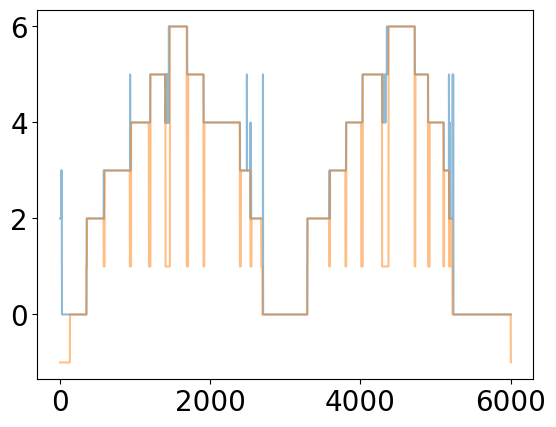

Accuracy: 0.9910
Exit predicted at frame 354 Pred: 0 -> 2)
Exit predicted at frame 2538 Pred: 4 -> 2)
Exit predicted at frame 3292 Pred: 0 -> 2)
Exit predicted at frame 5180 Pred: 4 -> 2)
Confusion Matrix for Presence Classification: [[1685  433]
 [   0 3886]]
Confusion Matrix for Posture Classification (Detailed): [[1571    9    0    0   14    0]
 [   0  661    0    0    0    0]
 [   0    0  731    0    2    0]
 [   0    0    0 1091    0    0]
 [   0    0    0    0  830    0]
 [   0    0    0    0    0  571]]


In [11]:
# Cross env 2
if __name__ == "__main__":
    # office0_4: 0.9919028340080972 len 12274
    # hall5: 0.9850 len 2394
    # office0_1: 0.9964912280701754, len 2963
    # office0_2: 0.9953646275380297, len 15525
    # office1_0: 0.9964, len 5433
    # office2_0: 0.9913, len 6004
    # home01: 
    env = "office2_0"
    model = "posture_cnn_cross_env_env6"
    tag = "cross_env"
    # tag = "nopostprocess_exp"
    k = 0.005
    corr = -0.75
    # test_inference(env, model_path=f'/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/weights/weights_final/{model}_0417.pth', tag = tag, k = k, corr = corr)
    vis_results(env, tag)

in_env test:  0.9964912280701754
cross_env test:  0.9567978750082492
cross user test: 0.9759032133923418


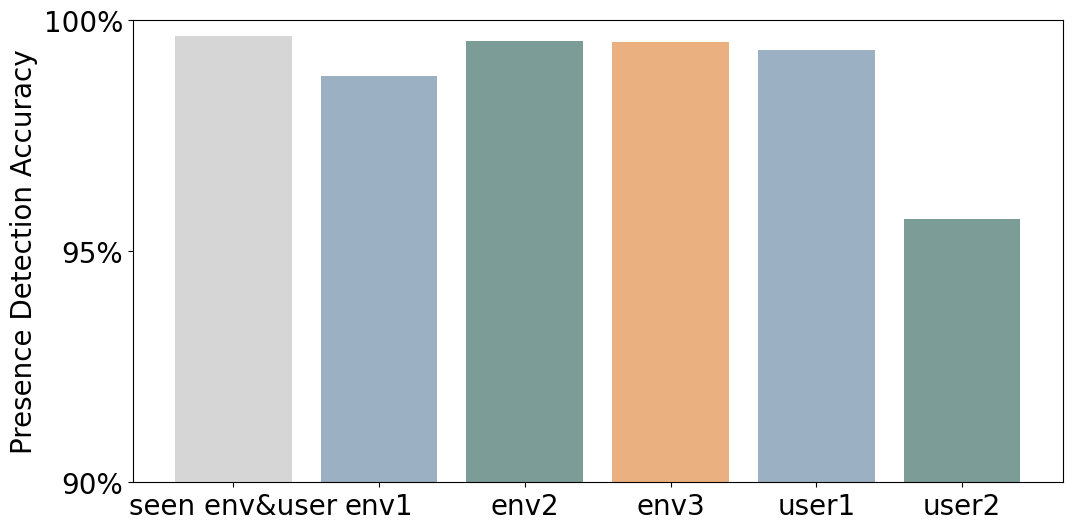

<Figure size 640x480 with 0 Axes>

In [62]:
# Presence Accuracy
acc_lst_presence = [
    0.9964912280701754, # office 0
    0.987881320518178, # hall5 2394
    0.9954977488744372, # office1_0 6186
    0.9953995569943772, # office2_0 6004
    0.993633107839236, #sf 2691
    0.9569672131147541, #lcx 2506
    # 0.85514 # YSL0
]

print("in_env test: ", acc_lst_presence[0])
print("cross_env test: ", (0.9953*6004 + 0.9954*6186 + 0.9879*2394) / (6004 + 6186 + 2963))
print("cross user test:", (0.9569 * 2506 + 0.9936*2691) / (2506 + 2691))
# plot bar chart for acc_lst
import matplotlib.pyplot as plt
# set size
plt.figure(figsize=(12, 6))
# set font size
plt.rcParams.update({'font.size': 20})
env_names = ['seen env&user', 'env1', 'env2', 'env3', 'user1', 'user2']
# colors set to: #D6D6D6, #9CB0C3, #7C9D97, #EAB080
colors = ['#D6D6D6', '#9CB0C3', '#7C9D97', '#EAB080', '#9CB0C3', '#7C9D97']
plt.bar(env_names, acc_lst_presence, color=colors)
plt.ylim(0.98, 1)
# set y ticks to show percentage, e.g. 98%, 99%, 100%
plt.yticks([0.90, 0.95, 1], ['90%', '95%', '100%'])
plt.xlabel("")
plt.ylabel("Presence Detection Accuracy")
plt.show()
# save to pdf
plt.savefig("presence_detection_accuracy.pdf")

in_env test:  0.9964912280701754
cross_env test:  0.9567978750082492
cross user test: 0.9759032133923418


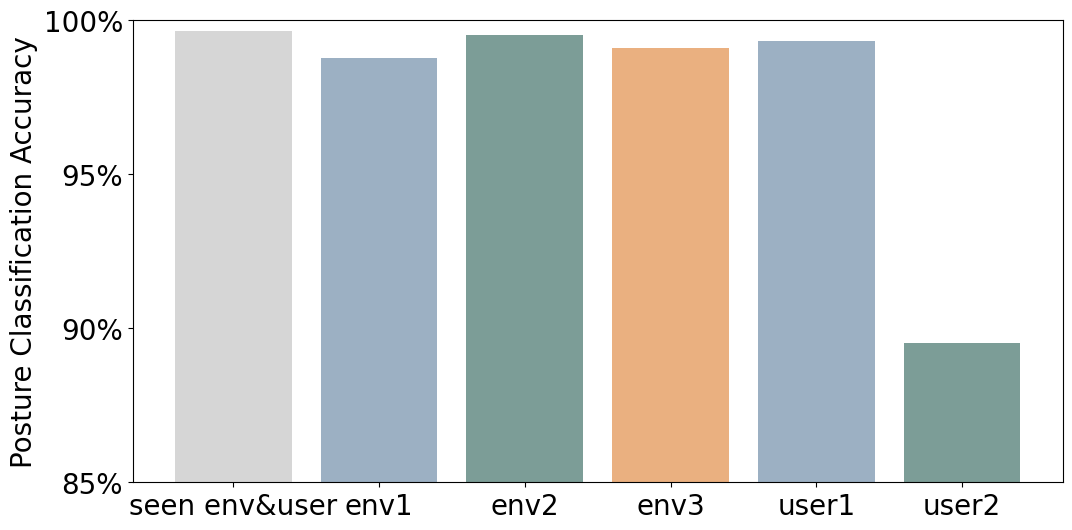

<Figure size 640x480 with 0 Axes>

In [63]:
# Posture Accuracy
# Presence Accuracy
acc_lst_poses = [
    0.9964912280701754, # office 0
    0.9879, # hall5 2394
    0.9953, # office1_0 6186
    0.9910, # office2_0 6004
    0.9933, #sf 2691
    0.8951, #lcx 2506
    # 0.85514 # YSL0
]

print("in_env test: ", acc_lst_poses[0])
print("cross_env test: ", (0.9953*6004 + 0.9954*6186 + 0.9879*2394) / (6004 + 6186 + 2963))
print("cross user test:", (0.9569 * 2506 + 0.9936*2691) / (2506 + 2691))
# plot bar chart for acc_lst
import matplotlib.pyplot as plt
# set size
plt.figure(figsize=(12, 6))
# set font size
plt.rcParams.update({'font.size': 20})
env_names = ['seen env&user', 'env1', 'env2', 'env3', 'user1', 'user2']
# colors set to: #D6D6D6, #9CB0C3, #7C9D97, #EAB080
colors = ['#D6D6D6', '#9CB0C3', '#7C9D97', '#EAB080', '#9CB0C3', '#7C9D97']
plt.bar(env_names, acc_lst_poses, color=colors)
plt.ylim(0.98, 1)
# set y ticks to show percentage, e.g. 98%, 99%, 100%
plt.yticks([0.85, 0.90, 0.95, 1], ['85%', '90%', '95%', '100%'])
plt.xlabel("")
plt.ylabel("Posture Classification Accuracy")
plt.show()
# save to pdf
plt.savefig("posture_detection_accuracy.pdf")

in_env test:  0.9940918905115149
cross_env test:  0.991927875
cross user test: 0.9435088192625253


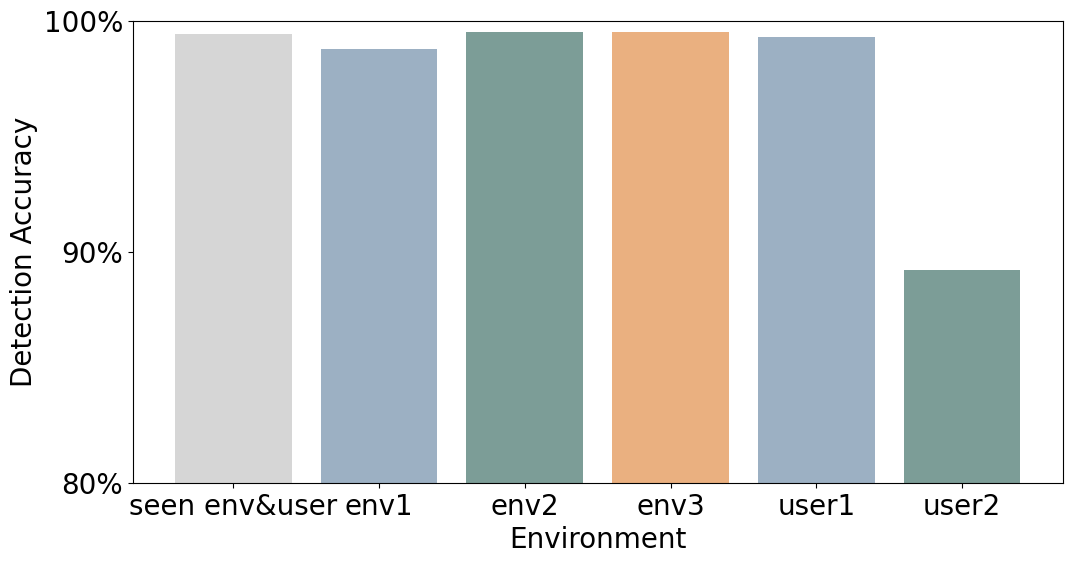

<Figure size 640x480 with 0 Axes>

In [61]:
# Oveall prediction accuracy
acc_lst_overall = [
    (12274*0.9919028340080972 + 2963*0.9964912280701754 + 15525*0.9953646275380297)/(12274 + 2963 + 15525), # office 0
    0.987881320518178, # hall5
    0.9951642487910622, #office 1_0
    0.9950587834384051, # office 2_0
    0.9928372463191405, # user 1
    0.8922131147540984, # user 2
]

print("in_env test: ", acc_lst_overall[0])
print("cross_env test: ", (0.9964*5433 + 0.9913*6004 + 0.9850*2963) / (5433 + 6004 + 2963))
print("cross user test:", (0.8913934426229508 * 2506 + 0.9920413847990449*2691) / (2506 + 2691))
# plot bar chart for acc_lst
import matplotlib.pyplot as plt
# set size
plt.figure(figsize=(12, 6))
# set font size
plt.rcParams.update({'font.size': 20})
env_names = ['seen env&user', 'env1', 'env2', 'env3', 'user1', 'user2']
# colors set to: #D6D6D6, #9CB0C3, #7C9D97, #EAB080
colors = ['#D6D6D6', '#9CB0C3', '#7C9D97', '#EAB080', '#9CB0C3', '#7C9D97']
plt.bar(env_names, acc_lst_overall, color=colors)
plt.ylim(0.98, 1)
# set y ticks to show percentage, e.g. 98%, 99%, 100%
plt.yticks([0.80, 0.90, 1], ['80%', '90%', '100%'])
plt.xlabel("Environment")
plt.ylabel("Detection Accuracy")
plt.show()
# save to pdf
plt.savefig("posture_detection_accuracy.pdf")

In [ ]:
# plot acc_lst_presence, acc_lst_poses, acc_lst_overall in one figure
import matplotlib.pyplot as plt
# set size
plt.figure(figsize=(12, 6))
# set font size
plt.rcParams.update({'font.size': 20})
env_names = ['seen env&user', 'env1', 'env2', 'env3', 'user1', 'user2']
# color of presence: #DDDDDD
# color of posture: #E6B745
# color of overall: #D0DD97
# for each env/type/user, plot three attributes clustered together

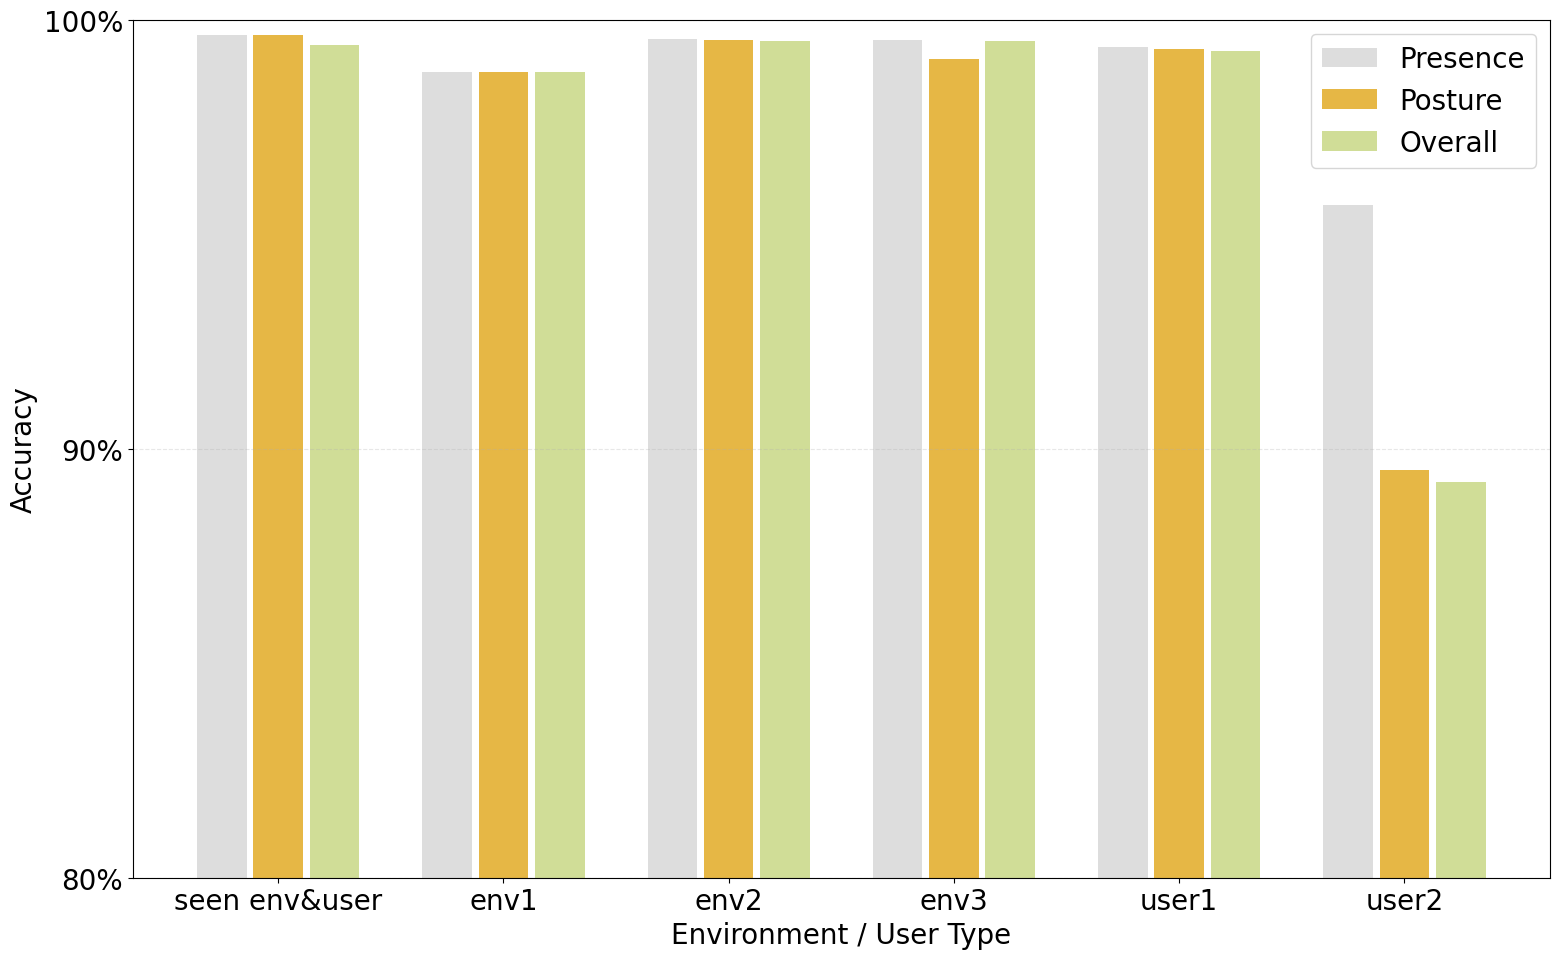

In [70]:
import matplotlib.pyplot as plt
import numpy as np

# Set figure size and font size
plt.figure(figsize=(16, 10))
plt.rcParams.update({'font.size': 20})

# Your data (replace with your actual lists)
# acc_lst_presence = [...]
# acc_lst_poses = [...]
# acc_lst_overall = [...]

env_names = ['seen env&user', 'env1', 'env2', 'env3', 'user1', 'user2']

# Colors as specified
color_presence = '#DDDDDD'
color_poses = '#E6B745'
color_overall = '#D0DD97'

# Number of groups
n_groups = len(env_names)
indices = np.arange(n_groups)

# Bar width
bar_width = 0.22
spacing = 0.03

# Create clustered bars
plt.bar(indices - bar_width - spacing, acc_lst_presence, bar_width, 
        label='Presence', color=color_presence, linewidth=1.2)

plt.bar(indices, acc_lst_poses, bar_width, 
        label='Posture', color=color_poses, linewidth=1.2)

plt.bar(indices + bar_width + spacing, acc_lst_overall, bar_width, 
        label='Overall', color=color_overall, linewidth=1.2)

# Labels and title
plt.xlabel('Environment / User Type')
plt.ylabel('Accuracy')
# plt.title('Accuracy Comparison: Presence, Posture, and Overall')

# Set x-ticks with environment names
plt.xticks(indices, env_names, rotation=0)

# set y limits
plt.ylim(0.98, 1)
plt.yticks([0.80, 0.90, 1], ['80%', '90%', '100%'])

# Add legend
plt.legend(loc='upper right', frameon=True, fancybox=True)

# Add grid for better readability (optional)
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Tight layout and show
plt.tight_layout()
plt.savefig("accuracy_comparison.png")
plt.show()
# save as pdf


Overall Accuracy: 0.9858
                  precision    recall  f1-score   support

          Absent     0.9955    0.9652    0.9801     12978
        Standing     0.9562    0.9882    0.9720      4755
  Sitting by Bed     0.9751    1.0000    0.9874      6107
  Sitting on Bed     0.9997    0.9823    0.9909      8847
 Lying w/o Cover     0.9745    0.9993    0.9868      8921
Lying with Cover     0.9986    1.0000    0.9993      5529

        accuracy                         0.9858     47137
       macro avg     0.9833    0.9892    0.9861     47137
    weighted avg     0.9861    0.9858    0.9858     47137



<Figure size 3600x2400 with 0 Axes>

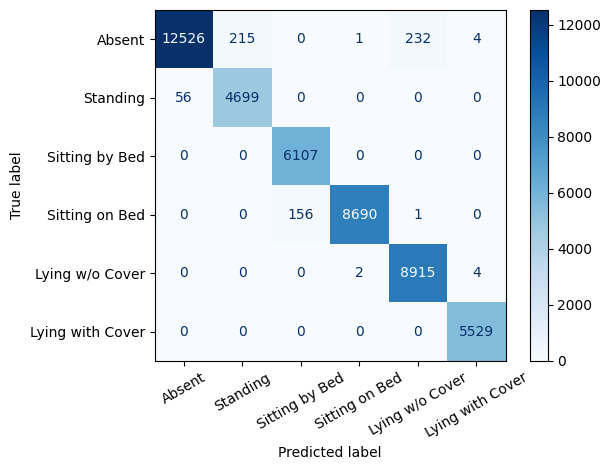

In [28]:
# go through all nopostprocess_exp and cross_user_exp json files
# collect all data
# draw confusion matrix
gt = []
pred = []
file_names = ['office0_0_nopostprocess_exp', 'office0_2_nopostprocess_exp', 'office0_3_nopostprocess', 'office0_4_nopostprocess_exp', 'hall5_nopostprocess_exp', 'office1_0_nopostprocess_exp', 'office2_0_nopostprocess_exp', 'office0_lcx_1_cross_user']

for file_name in file_names:
    with open(f'/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/output/previous/{file_name}.json', 'r') as f:
        data = json.load(f)
        results = data['results']
        gt_result_lst = data['gt_result_lst']
        for i in range(len(gt_result_lst)):
            gt_label = gt_result_lst[i]
            pred_label = results[i]
            if gt_label == -1 or gt_label == 1:
                continue
            else:
                gt.append(gt_label)
                pred.append(pred_label)

# draw confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(gt, pred, labels=[0, 2, 3, 4, 5, 6])
plt.figure(figsize=(36, 24))
# adjust layout to make room for labels
plt.subplots_adjust(left=0.5, bottom=0.5)

# text sizes
plt.rcParams.update({'font.size': 10})
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Absent', 'Standing', 'Sitting by Bed', 'Sitting on Bed', 'Lying w/o Cover', 'Lying with Cover'])
disp.plot(cmap=plt.cm.Blues)
# rotate x label by 45 degree
plt.xticks(rotation=30)
# plt.title("Confusion Matrix for Posture Classification (Detailed)")
# save as pdf
plt.tight_layout()
plt.savefig("posture_classification_confusion_matrix.pdf") # figure cropped away the left and lower part. we adjust layout
# print accuracy
accuracy = sum([1 if p == g else 0 for p, g in zip(pred, gt)]) / len(gt)
print(f"Overall Accuracy: {accuracy:.4f}")
# print acc, precision, recall, f1 score of all classes
from sklearn.metrics import classification_report
# need 4 decimals for precision, recall, f1 score
report = classification_report(gt, pred, labels=[0, 2, 3, 4, 5, 6], target_names=['Absent', 'Standing', 'Sitting by Bed', 'Sitting on Bed', 'Lying w/o Cover', 'Lying with Cover'], digits=4)
print(report)

# Ablation study: presence detection
0. Vanilla per-frame
1. use non-kalman tracker
2. use kalman tracker + non-functional residual detection (do not label isResidual as True)
3. full power

In [39]:
# Full-power presence detector
from organizer_module.track_kalman import Tracker
# use data entries: hall5, office1_0, office2_0, office0_4
def test_inference(data_name=data_name, model_path = '/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/weights/all_current_data.pth', tag = "", k = None):
    # use a data entry as test: /Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/data/hall5
    
    # 1. load the dataset ===============================================
    # dataset = ThermalDataset("/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/data/office1_0")
    dataset = ThermalDataset(f"/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/data/{data_name}", noCam = True)
    print(f"dataset {data_name}; length:", len(dataset))


    # 2. initialize our system's components ==================================
    #   2.1. heatsource detection module: load the module
    heat_detector = HeatSourceDetector()
    thermalinvariantpreprocessor = ThermalInvariantPreprocessor()
    #   2.1. posture detector module: load the model
    posture_detector_model = SimpleIRA_CNN()
    # load the pretrained weights for posture detection model
    posture_detector_model.load_state_dict(torch.load('/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/weights/all_current_data.pth'))
    #   2.2. kalman tracker module: load the module

    tracker = Tracker(k_thresh = 0.005, velocity_thresh= 1, temp_decrease_thresh=-0.75)
    
    #   2.4. postprocessor module: load the module
    postprocessor = PostProcessor()

    import matplotlib.pyplot as plt
    from tqdm import tqdm
    

    # 3. loop through each fraome ========================================
    #   3.1. prepare the ground truth label list
    gt_result_lst = []
    waittime = 1
    visualization = False
    for idx in tqdm(range(0, len(dataset), 1)):
        # gt
        label = dataset.annotations_expanded[idx]
        gt_result_lst.append(label)

        # data
        ira_highres = dataset.get_ira_highres(idx)
        # make pixels less than 17 deg be 17 deg
        ira_highres[ira_highres < 18] = 18

        # plt.imshow(ira_highres)
        # plt.show()

        #   3.1. detect heat source
        thresh, mask = heat_detector.get_thresh_mask_otsu(ira_highres)
        
        mask_individual = heat_detector.process_frame_connected_components(ira_highres, min_size=100)

        #   3.2. detect presence with kalman tracker
        tracker.update_blobs(mask_individual, ira_highres, heat_detector.get_unmasked_mean(ira_highres, mask), idx)
        postprocessor.get_blobs(tracker.blobs, idx)

        #   3.3. posture detection if kalman shows presence; record it in postprocessor
        hasHuman = False
        for blob in tracker.blobs:
            if blob.is_residual == False: # if it is classified as human
                hasHuman = True

        if hasHuman:
            # clip and normalize the ira_highres image, and convert to tensor before feeding into the posture detection model
            ira_highres = thermalinvariantpreprocessor(ira_highres)
            posture = posture_detector_model(torch.tensor(ira_highres, dtype=torch.float32).unsqueeze(0)) # add batch and channel dimension
            posture_label = torch.argmax(posture, dim=1).item()
            # print("DEBUG: posture label: ", posture_label)
            posture_label = inverse_remap_labels_simple(posture_label)  # remap the posture label
            # print("DEBUG: inverse remap posture label: ", posture_label)
            postprocessor.get_posture(posture_label, idx)  # inverse remap the posture label
            posture_str = label_to_text_simple(posture_label)
        else:
            posture_label = 0
            posture_str = label_to_text_simple(posture_label)
            postprocessor.get_posture(0, idx)

        # visualize the result for this frame
        if visualization:
            visualize_frame(ira_highres, tracker.blobs, posture_str, idx, 10)
    
    # 4. save the results to /Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/output/{data_name}.json
    with open(f'/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/output/{data_name}_{tag}.json', 'w') as f:
        json.dump({'results': postprocessor.posture_records, 'gt_result_lst': gt_result_lst}, f, indent=4)

    # draw the confusion matrix for posture classificatino result
    # confusion_matrix_draw(postprocessor.posture_records, gt_result_lst)

data_test_names = []
data_test_names = ['office0_lcx_1']

tag = "ablation_full"
# for data_name in data_test_names:
#     test_inference(data_name=data_name, model_path=f'/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/weights/posture_cnn_all_full.pth', tag = tag, k = 0.004)
    
def summarize_results(data_names, tag):
    import json
    correct = 0
    total = 0
    # load all json files and summarize the acc
    for data_name in data_names:
        correct_local = 0
        total_local = 0
        with open(f'/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/output/{data_name}_{tag}.json', 'r') as f:
            data = json.load(f)
            results = data['results']
            gt_result_lst = data['gt_result_lst']
            # compute accuracy
            for i in range(len(gt_result_lst)):
                gt = gt_result_lst[i]
                pred = results[i]
                if gt == -1:
                    continue
                if gt == 1:
                    if pred in [2, 3, 4, 5, 6]:
                        correct += 1
                        correct_local += 1
                else:
                    if pred == gt:
                        correct += 1
                        correct_local += 1
                total += 1
                total_local += 1
        accuracy_local = correct_local / total_local if total_local > 0 else 0
        print(f"Accuracy for {data_name}: {accuracy_local:.4f}")
    accuracy = correct / total
    print(f"Overall acc: {accuracy:.4f}")
# summarize results: pose acc
# data_test_names = ['hall5', 'office1_0', 'office2_0', 'office0_3', 'office0_sf_0', 'office0_lcx_1']
summarize_results(data_test_names, tag)

Accuracy for office0_lcx_1: 0.8934
Overall acc: 0.8934


In [38]:
# No tracker, only per-frame detection
# use data entries: hall5, office1_0, office2_0, office0_4
def test_inference(data_name=data_name, model_path = '/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/weights/all_current_data.pth', tag = "", k = None):
    # use a data entry as test: /Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/data/hall5
    
    # 1. load the dataset ===============================================
    # dataset = ThermalDataset("/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/data/office1_0")
    dataset = ThermalDataset(f"/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/data/{data_name}", noCam = True)
    print(f"dataset {data_name}; length:", len(dataset))


    # 2. initialize our system's components ==================================
    #   2.1. heatsource detection module: load the module
    heat_detector = HeatSourceDetector()
    thermalinvariantpreprocessor = ThermalInvariantPreprocessor()
    #   2.1. posture detector module: load the model
    posture_detector_model = SimpleIRA_CNN()
    # load the pretrained weights for posture detection model
    posture_detector_model.load_state_dict(torch.load('/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/weights/all_current_data.pth'))
    #   2.2. kalman tracker module: load the module
    
    # tracker = Tracker(k_thresh = 0.005, velocity_thresh= 1, temp_decrease_thresh=-0.75)
    #   2.4. postprocessor module: load the module
    postprocessor = PostProcessor()

    import matplotlib.pyplot as plt
    from tqdm import tqdm
    

    # 3. loop through each fraome ========================================
    #   3.1. prepare the ground truth label list
    gt_result_lst = []
    waittime = 1
    visualization = False
    for idx in tqdm(range(0, len(dataset), 1)):
        # gt
        label = dataset.annotations_expanded[idx]
        gt_result_lst.append(label)

        # data
        ira_highres = dataset.get_ira_highres(idx)
        # make pixels less than 17 deg be 17 deg
        ira_highres[ira_highres < 18] = 18

        # plt.imshow(ira_highres)
        # plt.show()

        #   3.1. detect heat source
        thresh, mask = heat_detector.get_thresh_mask_otsu(ira_highres)
        
        # check if pixels above thresold's values's avg is higher than the unmasked mean by a certain value (e.g. 5 degree)
        unmasked_mean = heat_detector.get_unmasked_mean(ira_highres, mask)
        # print("shape of mask: ", mask.shape)
        # print("shape of ira_highres: ", ira_highres.shape)
        mask_bool = mask.astype(bool)
        if (ira_highres * mask_bool).sum() > 0:
            masked_mean = ira_highres[mask_bool].mean() if mask_bool.sum() > 0 else 0
            if masked_mean - unmasked_mean > 6.5:
                hasHuman = True
            else:
                hasHuman = False
        else:
            hasHuman = False

        
        mask_individual = heat_detector.process_frame_connected_components(ira_highres, min_size=100)

        #   3.2. detect presence with kalman tracker
        # tracker.update_blobs(mask_individual, ira_highres, heat_detector.get_unmasked_mean(ira_highres, mask), idx)
        # postprocessor.get_blobs(tracker.blobs, idx)

        #   3.3. posture detection if kalman shows presence; record it in postprocessor
        # hasHuman = len(mask_individual) > 0

        if hasHuman:
            # clip and normalize the ira_highres image, and convert to tensor before feeding into the posture detection model
            ira_highres = thermalinvariantpreprocessor(ira_highres)
            posture = posture_detector_model(torch.tensor(ira_highres, dtype=torch.float32).unsqueeze(0)) # add batch and channel dimension
            posture_label = torch.argmax(posture, dim=1).item()
            # print("DEBUG: posture label: ", posture_label)
            posture_label = inverse_remap_labels_simple(posture_label)  # remap the posture label
            # print("DEBUG: inverse remap posture label: ", posture_label)
            postprocessor.get_posture(posture_label, idx)  # inverse remap the posture label
            posture_str = label_to_text_simple(posture_label)
        else:
            posture_label = 0
            posture_str = label_to_text_simple(posture_label)
            postprocessor.get_posture(0, idx)

        # visualize the result for this frame
        if visualization:
            visualize_frame(ira_highres, tracker.blobs, posture_str, idx, 10)
    
    # 4. save the results to /Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/output/{data_name}.json
    with open(f'/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/output/{data_name}_{tag}.json', 'w') as f:
        json.dump({'results': postprocessor.posture_records, 'gt_result_lst': gt_result_lst}, f, indent=4)


# data_test_names = ['hall5', 'office1_0', 'office2_0', 'office0_3', 'office0_sf_0', 'office0_lcx_1']
data_test_names = ['office0_lcx_1']

tag = "ablation_nofilt_noclassifier"
def test_ablation():
    for data_name in data_test_names:
        test_inference(data_name=data_name, model_path=f'/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/weights/posture_cnn_all_full.pth', tag = tag, k = 0.004)

# test_ablation()

# ====================

# plot the results
def vis_results(data_name = "office0_4", tag = ""):
    # visualize the results in /Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/output/{data_name}_nopostprocess_exp.json
    # data_name = "home01"
    vis_json_results(data_name, tag)

# for name in data_test_names:
#     vis_results(name, tag)
def summarize_results(data_names, tag):
    import json
    # load all json files and summarize the acc
    correct = 0
    total = 0
    
    for data_name in data_names:
        with open(f'/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/output/{data_name}_{tag}.json', 'r') as f:
            data = json.load(f)
            results = data['results']
            gt_result_lst = data['gt_result_lst']
            # compute accuracy

            for i in range(len(gt_result_lst)):
                gt = gt_result_lst[i]
                pred = results[i]
                if gt == -1:
                    continue
                if gt == 1:
                    if pred in [2, 3, 4, 5, 6]:
                        correct += 1
                else:
                    if pred == gt:
                        correct += 1
                total += 1
    accuracy = correct / total
    print(f"Accuracy for {data_names}: {accuracy:.4f}")


# # summarize results: pose acc
summarize_results(data_test_names, tag)




Accuracy for ['office0_lcx_1']: 0.5115


In [36]:
# Yes tracker, no Kalman
from organizer_module.track_no_filter import Tracker
# use data entries: hall5, office1_0, office2_0, office0_4
def test_inference(data_name=data_name, model_path = '/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/weights/all_current_data.pth', tag = "", k = None):
    # use a data entry as test: /Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/data/hall5
    
    # 1. load the dataset ===============================================
    # dataset = ThermalDataset("/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/data/office1_0")
    dataset = ThermalDataset(f"/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/data/{data_name}", noCam = True)
    print(f"dataset {data_name}; length:", len(dataset))


    # 2. initialize our system's components ==================================
    #   2.1. heatsource detection module: load the module
    heat_detector = HeatSourceDetector()
    thermalinvariantpreprocessor = ThermalInvariantPreprocessor()
    #   2.1. posture detector module: load the model
    posture_detector_model = SimpleIRA_CNN()
    # load the pretrained weights for posture detection model
    posture_detector_model.load_state_dict(torch.load('/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/weights/all_current_data.pth'))
    #   2.2. kalman tracker module: load the module
    tracker = Tracker()

    #   2.4. postprocessor module: load the module
    postprocessor = PostProcessor()

    import matplotlib.pyplot as plt
    from tqdm import tqdm
    

    # 3. loop through each fraome ========================================
    #   3.1. prepare the ground truth label list
    gt_result_lst = []
    pred_lst = []

    waittime = 1
    visualization = False
    for idx in tqdm(range(0, len(dataset), 1)):
        # gt
        label = dataset.annotations_expanded[idx]
        gt_result_lst.append(label)

        # data
        ira_highres = dataset.get_ira_highres(idx)
        # make pixels less than 17 deg be 17 deg
        ira_highres[ira_highres < 18] = 18

        # plt.imshow(ira_highres)
        # plt.show()

        #   3.1. detect heat source
        thresh, mask = heat_detector.get_thresh_mask_otsu(ira_highres)
        
        mask_individual = heat_detector.process_frame_connected_components(ira_highres, min_size=100)

        #   3.2. detect presence with kalman tracker
        tracker.update_blobs(mask_individual, ira_highres, heat_detector.get_unmasked_mean(ira_highres, mask))
        # postprocessor.get_blobs(tracker.blobs, idx)

        #   3.3. posture detection if kalman shows presence; record it in postprocessor
        hasHuman = len(mask_individual) > 0

        if hasHuman:
            # clip and normalize the ira_highres image, and convert to tensor before feeding into the posture detection model
            ira_highres = thermalinvariantpreprocessor(ira_highres)
            posture = posture_detector_model(torch.tensor(ira_highres, dtype=torch.float32).unsqueeze(0)) # add batch and channel dimension
            posture_label = torch.argmax(posture, dim=1).item()
            # print("DEBUG: posture label: ", posture_label)
            posture_label = inverse_remap_labels_simple(posture_label)  # remap the posture label
            # print("DEBUG: inverse remap posture label: ", posture_label)
            # postprocessor.get_posture(posture_label, idx)  # inverse remap the posture label
            pred_lst.append(posture_label)
            posture_str = label_to_text_simple(posture_label)
        else:
            posture_label = 0
            posture_str = label_to_text_simple(posture_label)
            # postprocessor.get_posture(0, idx)
            pred_lst.append(posture_label)

        # visualize the result for this frame
        if visualization:
            visualize_frame(ira_highres, tracker.blobs, posture_str, idx, 10)
    
    # 4. save the results to /Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/output/{data_name}.json
    with open(f'/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/output/{data_name}_{tag}.json', 'w') as f:
        json.dump({'results': pred_lst, 'gt_result_lst': gt_result_lst}, f, indent=4)

    # draw the confusion matrix for posture classificatino result
    # confusion_matrix_draw(postprocessor.posture_records, gt_result_lst)

data_test_names = ['hall5', 'office1_0', 'office2_0', 'office0_3', 'office0_sf_0', 'office0_lcx_1']
data_test_names = ['office0_lcx_1']
data_test_names = ['office0_lcx_1']

tag = "ablation_nofilt_withclassifier"
def test_ablation():
    for data_name in data_test_names:
        test_inference(data_name=data_name, model_path=f'/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/weights/posture_cnn_all_full.pth', tag = tag, k = 0.004)

# test_ablation()


# for name in data_names:
#     vis_results(name, tag)
# summarize results: pose acc
summarize_results(data_test_names, tag)

NameError: name 'summarize_results' is not defined

In [ ]:
# from organizer_module.track_kalman_noResDet import Tracker
# # Yes tracker, yes kalman, no heat history based classification
# # use data entries: hall5, office1_0, office2_0, office0_4
# def test_inference(data_name=data_name, model_path = '/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/weights/all_current_data.pth', tag = "", k = None):
#     # use a data entry as test: /Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/data/hall5
    
#     # 1. load the dataset ===============================================
#     # dataset = ThermalDataset("/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/data/office1_0")
#     dataset = ThermalDataset(f"/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/data/{data_name}", noCam = True)
#     print(f"dataset {data_name}; length:", len(dataset))


#     # 2. initialize our system's components ==================================
#     #   2.1. heatsource detection module: load the module
#     heat_detector = HeatSourceDetector()
#     thermalinvariantpreprocessor = ThermalInvariantPreprocessor()
#     #   2.1. posture detector module: load the model
#     posture_detector_model = SimpleIRA_CNN()
#     # load the pretrained weights for posture detection model
#     posture_detector_model.load_state_dict(torch.load('/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/weights/all_current_data.pth'))
#     #   2.2. kalman tracker module: load the module
#     if k is not None:
#         tracker = Tracker(k_thresh = k)
#     else:
#         tracker = Tracker(k_thresh = 0.005, velocity_thresh= 1, temp_decrease_thresh=-0.75)
#     #   2.4. postprocessor module: load the module
#     postprocessor = PostProcessor()

#     import matplotlib.pyplot as plt
#     from tqdm import tqdm
    

#     # 3. loop through each fraome ========================================
#     #   3.1. prepare the ground truth label list
#     gt_result_lst = []
#     waittime = 1
#     visualization = False
#     for idx in tqdm(range(0, len(dataset), 1)):
#         # gt
#         label = dataset.annotations_expanded[idx]
#         gt_result_lst.append(label)

#         # data
#         ira_highres = dataset.get_ira_highres(idx)
#         # make pixels less than 17 deg be 17 deg
#         ira_highres[ira_highres < 18] = 18

#         # plt.imshow(ira_highres)
#         # plt.show()

#         #   3.1. detect heat source
#         thresh, mask = heat_detector.get_thresh_mask_otsu(ira_highres)
        
#         mask_individual = heat_detector.process_frame_connected_components(ira_highres, min_size=100)

#         #   3.2. detect presence with kalman tracker
#         tracker.update_blobs(mask_individual, ira_highres, heat_detector.get_unmasked_mean(ira_highres, mask), idx)
#         postprocessor.get_blobs(tracker.blobs, idx)

#         #   3.3. posture detection if kalman shows presence; record it in postprocessor
#         hasHuman = len(mask_individual) > 0

#         if hasHuman:
#             # clip and normalize the ira_highres image, and convert to tensor before feeding into the posture detection model
#             ira_highres = thermalinvariantpreprocessor(ira_highres)
#             posture = posture_detector_model(torch.tensor(ira_highres, dtype=torch.float32).unsqueeze(0)) # add batch and channel dimension
#             posture_label = torch.argmax(posture, dim=1).item()
#             # print("DEBUG: posture label: ", posture_label)
#             posture_label = inverse_remap_labels_simple(posture_label)  # remap the posture label
#             # print("DEBUG: inverse remap posture label: ", posture_label)
#             postprocessor.get_posture(posture_label, idx)  # inverse remap the posture label
#             posture_str = label_to_text_simple(posture_label)
#         else:
#             posture_label = 0
#             posture_str = label_to_text_simple(posture_label)
#             postprocessor.get_posture(0, idx)

#         # visualize the result for this frame
#         if visualization:
#             visualize_frame(ira_highres, tracker.blobs, posture_str, idx, 10)
    
#     # 4. save the results to /Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/output/{data_name}.json
#     with open(f'/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/output/{data_name}_{tag}.json', 'w') as f:
#         json.dump({'results': postprocessor.posture_records, 'gt_result_lst': gt_result_lst}, f, indent=4)

#     # draw the confusion matrix for posture classificatino result
#     # confusion_matrix_draw(postprocessor.posture_records, gt_result_lst)


# data_test_names = ['office0_lcx_1']
# data_test_names = ['office0_wjs_0']
# tag = "ablation_kalman_noClassifier"
# def test():
#     for data_name in data_test_names:
#         test_inference(data_name=data_name, model_path=f'/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/weights/posture_cnn_all_full.pth', tag = tag, k = 0.004)
# test()
# # summarize results: pose acc
# summarize_results(data_test_names, tag)

Accuracy for ['office0_wjs_0']: 0.4161


In [45]:
from organizer_module.track_kalman_noPostProcess import Tracker
# Yes tracker, yes kalman, only patch split based classification, no heat history based classification
# use data entries: hall5, office1_0, office2_0, office0_4
def test_inference(data_name=data_name, model_path = '/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/weights/all_current_data.pth', tag = "", k = None):
    # use a data entry as test: /Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/data/hall5
    
    # 1. load the dataset ===============================================
    # dataset = ThermalDataset("/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/data/office1_0")
    dataset = ThermalDataset(f"/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/data/{data_name}", noCam = True)
    print(f"dataset {data_name}; length:", len(dataset))


    # 2. initialize our system's components ==================================
    #   2.1. heatsource detection module: load the module
    heat_detector = HeatSourceDetector()
    thermalinvariantpreprocessor = ThermalInvariantPreprocessor()
    #   2.1. posture detector module: load the model
    posture_detector_model = SimpleIRA_CNN()
    # load the pretrained weights for posture detection model
    posture_detector_model.load_state_dict(torch.load('/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/weights/all_current_data.pth'))
    #   2.2. kalman tracker module: load the module
    tracker = Tracker(k_thresh = 0.005, velocity_thresh= 1, temp_decrease_thresh=-0.75)
    #   2.4. postprocessor module: load the module
    postprocessor = PostProcessor()

    import matplotlib.pyplot as plt
    from tqdm import tqdm
    

    # 3. loop through each fraome ========================================
    #   3.1. prepare the ground truth label list
    gt_result_lst = []
    waittime = 1
    visualization = False
    for idx in tqdm(range(0, len(dataset), 1)):
        # gt
        label = dataset.annotations_expanded[idx]
        gt_result_lst.append(label)

        # data
        ira_highres = dataset.get_ira_highres(idx)
        # make pixels less than 17 deg be 17 deg
        ira_highres[ira_highres < 18] = 18

        # plt.imshow(ira_highres)
        # plt.show()

        #   3.1. detect heat source
        thresh, mask = heat_detector.get_thresh_mask_otsu(ira_highres)
        
        mask_individual = heat_detector.process_frame_connected_components(ira_highres, min_size=100)

        #   3.2. detect presence with kalman tracker
        tracker.update_blobs(mask_individual, ira_highres, heat_detector.get_unmasked_mean(ira_highres, mask), idx)
        postprocessor.get_blobs(tracker.blobs, idx)

        #   3.3. posture detection if kalman shows presence; record it in postprocessor
        hasHuman = len(mask_individual) > 0

        if hasHuman:
            # clip and normalize the ira_highres image, and convert to tensor before feeding into the posture detection model
            ira_highres = thermalinvariantpreprocessor(ira_highres)
            posture = posture_detector_model(torch.tensor(ira_highres, dtype=torch.float32).unsqueeze(0)) # add batch and channel dimension
            posture_label = torch.argmax(posture, dim=1).item()
            # print("DEBUG: posture label: ", posture_label)
            posture_label = inverse_remap_labels_simple(posture_label)  # remap the posture label
            # print("DEBUG: inverse remap posture label: ", posture_label)
            postprocessor.get_posture(posture_label, idx)  # inverse remap the posture label
            posture_str = label_to_text_simple(posture_label)
        else:
            posture_label = 0
            posture_str = label_to_text_simple(posture_label)
            postprocessor.get_posture(0, idx)

        # visualize the result for this frame
        if visualization:
            visualize_frame(ira_highres, tracker.blobs, posture_str, idx, 10)
    
    # 4. save the results to /Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/output/{data_name}.json
    with open(f'/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/output/{data_name}_{tag}.json', 'w') as f:
        json.dump({'results': postprocessor.posture_records, 'gt_result_lst': gt_result_lst}, f, indent=4)

    # draw the confusion matrix for posture classificatino result
    # confusion_matrix_draw(postprocessor.posture_records, gt_result_lst)

data_test_names = ['hall5', 'office1_0', 'office2_0', 'office0_3', 'office0_sf_0', 'office0_lcx_1']
data_test_names = ['office0_lcx_1']

tag = "ablation_kalman_noPostProcess"
def test():
    for data_name in data_test_names:
        test_inference(data_name=data_name, model_path=f'/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/weights/posture_cnn_all_full.pth', tag = tag, k = 0.004)
# test()

# summarize results: pose acc
summarize_results(data_test_names, tag)
# done

Accuracy for office0_lcx_1: 0.6398
Overall acc: 0.6398


In [109]:
from organizer_module.track_kalman_noResDet import Tracker
# Yes tracker, yes kalman, no heat split based classification, only history based classification
# use data entries: hall5, office1_0, office2_0, office0_4
def test_inference(data_name=data_name, model_path = '/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/weights/all_current_data.pth', tag = "", k = None):
    # use a data entry as test: /Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/data/hall5
    
    # 1. load the dataset ===============================================
    # dataset = ThermalDataset("/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/data/office1_0")
    dataset = ThermalDataset(f"/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/data/{data_name}", noCam = True)
    print(f"dataset {data_name}; length:", len(dataset))


    # 2. initialize our system's components ==================================
    #   2.1. heatsource detection module: load the module
    heat_detector = HeatSourceDetector()
    thermalinvariantpreprocessor = ThermalInvariantPreprocessor()
    #   2.1. posture detector module: load the model
    posture_detector_model = SimpleIRA_CNN()
    # load the pretrained weights for posture detection model
    posture_detector_model.load_state_dict(torch.load('/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/weights/all_current_data.pth'))
    #   2.2. kalman tracker module: load the module
    tracker = tracker = Tracker(k_thresh = 0.005, temp_decrease_thresh=-0.75)
    #   2.4. postprocessor module: load the module
    postprocessor = PostProcessor()

    import matplotlib.pyplot as plt
    from tqdm import tqdm
    

    # 3. loop through each fraome ========================================
    #   3.1. prepare the ground truth label list
    gt_result_lst = []
    waittime = 1
    visualization = False
    for idx in tqdm(range(0, len(dataset), 1)):
        # gt
        label = dataset.annotations_expanded[idx]
        gt_result_lst.append(label)

        # data
        ira_highres = dataset.get_ira_highres(idx)
        # make pixels less than 17 deg be 17 deg
        ira_highres[ira_highres < 18] = 18

        # plt.imshow(ira_highres)
        # plt.show()

        #   3.1. detect heat source
        thresh, mask = heat_detector.get_thresh_mask_otsu(ira_highres)
        
        mask_individual = heat_detector.process_frame_connected_components(ira_highres, min_size=100)

        #   3.2. detect presence with kalman tracker
        tracker.update_blobs(mask_individual, ira_highres, heat_detector.get_unmasked_mean(ira_highres, mask), idx)
        postprocessor.get_blobs(tracker.blobs, idx)

        #   3.3. posture detection if kalman shows presence; record it in postprocessor
        hasHuman = len(mask_individual) > 0

        if hasHuman:
            # clip and normalize the ira_highres image, and convert to tensor before feeding into the posture detection model
            ira_highres = thermalinvariantpreprocessor(ira_highres)
            posture = posture_detector_model(torch.tensor(ira_highres, dtype=torch.float32).unsqueeze(0)) # add batch and channel dimension
            posture_label = torch.argmax(posture, dim=1).item()
            # print("DEBUG: posture label: ", posture_label)
            posture_label = inverse_remap_labels_simple(posture_label)  # remap the posture label
            # print("DEBUG: inverse remap posture label: ", posture_label)
            postprocessor.get_posture(posture_label, idx)  # inverse remap the posture label
            posture_str = label_to_text_simple(posture_label)
        else:
            posture_label = 0
            posture_str = label_to_text_simple(posture_label)
            postprocessor.get_posture(0, idx)

        # visualize the result for this frame
        if visualization:
            visualize_frame(ira_highres, tracker.blobs, posture_str, idx, 10)
    
    # 4. save the results to /Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/output/{data_name}.json
    with open(f'/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/output/{data_name}_{tag}.json', 'w') as f:
        json.dump({'results': postprocessor.posture_records, 'gt_result_lst': gt_result_lst}, f, indent=4)

    # draw the confusion matrix for posture classificatino result
    # confusion_matrix_draw(postprocessor.posture_records, gt_result_lst)

data_test_names = ['office0_lcx_1']
tag = "ablation_kalman_noClassifier"
def test():
    for data_name in data_test_names:
        test_inference(data_name=data_name, model_path=f'/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/weights/posture_cnn_all_full.pth', tag = tag, k = 0.004)
# test()
# summarize results: pose acc
summarize_results(data_test_names, tag)

Accuracy for office0_lcx_1: 0.6406
Overall acc: 0.6406


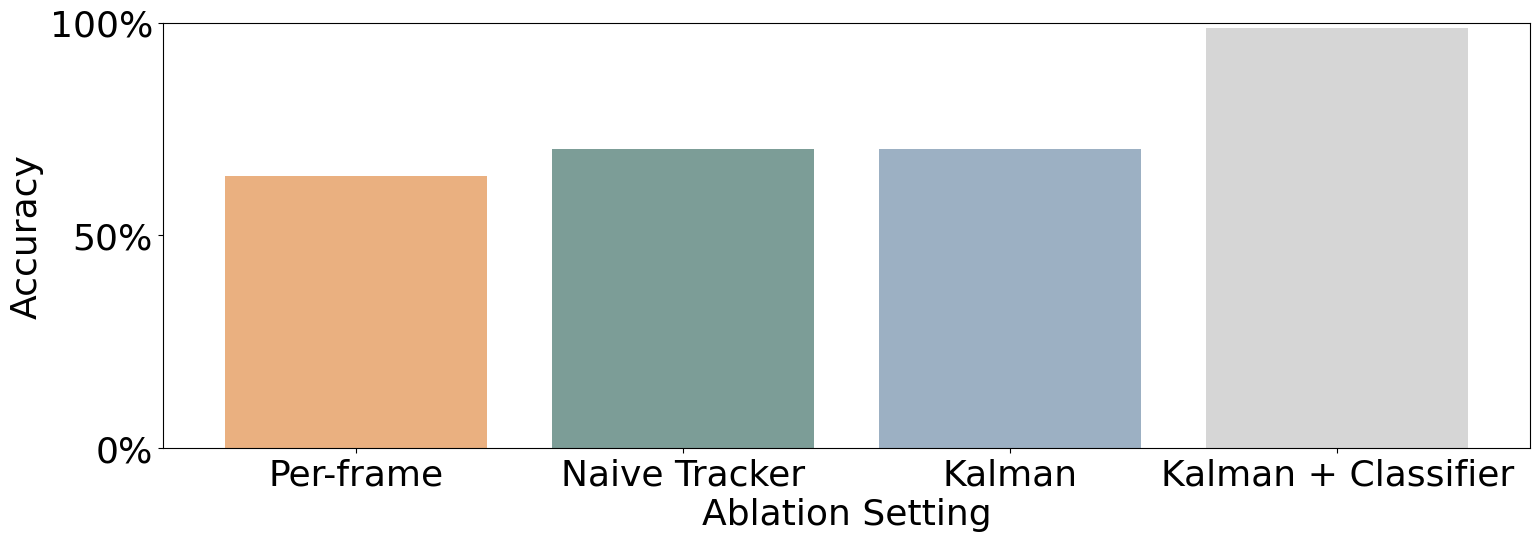

In [97]:
# Plot ablation result
# Per-fram detection: 0.5
# naive tracker (no prediction): 0.7036
# Kalman tracker only: 0.7034
# Kalman tracker + heat history based classification: 0.9873
presence_acc_lst = [
    0.9873, # full system
    0.7034, # Kalman tracker + no heat history based classification
    0.7036, # naive tracker (no prediction)
    0.6388, # per-frame detection
]
presence_acc_lst = presence_acc_lst[::-1] # reverse the list to make the bar chart in order of the ablation
import matplotlib.pyplot as plt
# set size
plt.figure(figsize=(16, 6))
# set font size
plt.rcParams.update({'font.size': 26})
env_names = ['Per-frame', 'Naive Tracker', 'Kalman', 'Kalman + Classifier']
# colors set to: #D6D6D6, #9CB0C3, #7C9D97, #EAB080
colors = ['#EAB080', '#7C9D97', '#9CB0C3', '#D6D6D6']
plt.bar(env_names, presence_acc_lst, color=colors)
plt.ylim(0, 1)
# set y ticks to show percentage, e.g. 0%, 50%, 100%
plt.yticks([0, 0.5, 1], ['0%', '50%', '100%'])
plt.xlabel("Ablation Setting")
plt.ylabel("Accuracy")
# plt.title("Ablation Study on Presence Detection Accuracy")
plt.tight_layout()
# save to pdf
plt.savefig("presence_detection_ablation.pdf")
plt.show()

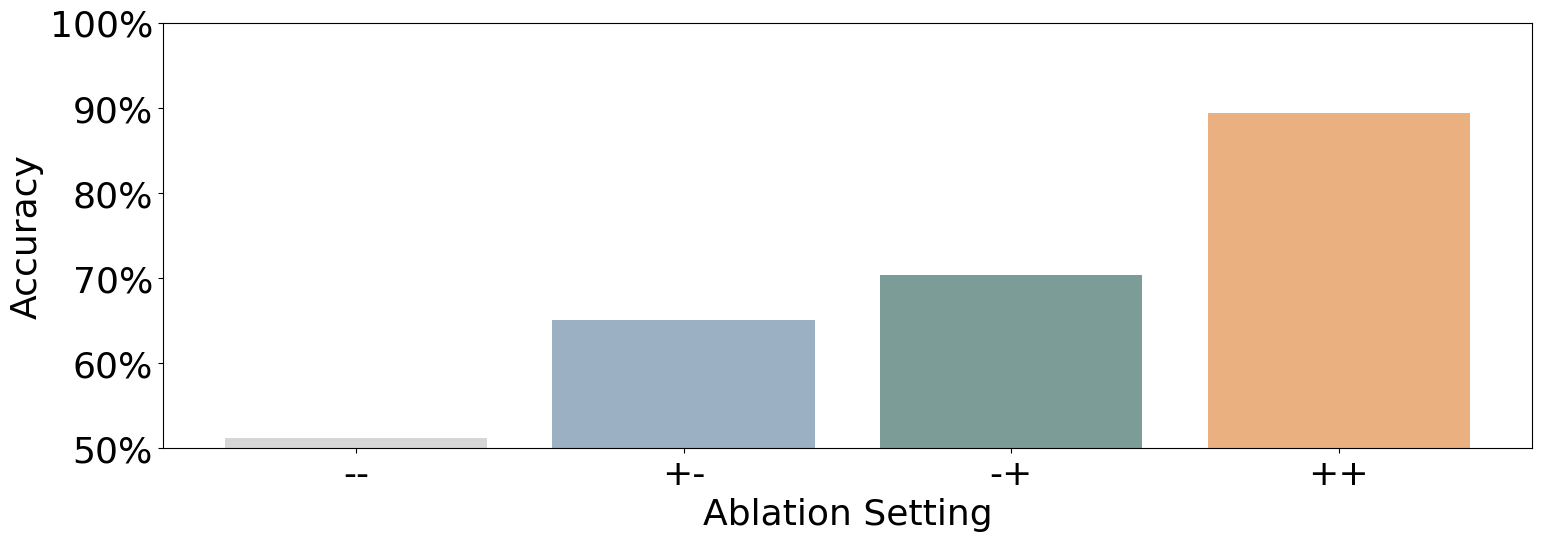

In [84]:
# Plot ablation result
# Per-fram detection: 0.5
# naive tracker (no prediction): 0.7036
# Kalman tracker only: 0.7034
# Kalman tracker + heat history based classification: 0.9873
presence_acc_lst = [
    0.5115, # per-frame only # 0.6389, # naive tracker (no prediction)
    0.6506, # Kalman tracker + no heat history based classification
    0.7036, # Kalman tracker + split event based classification
    0.8934 # full system
]
presence_acc_lst = presence_acc_lst[::] # reverse the list to make the bar chart in order of the ablation
import matplotlib.pyplot as plt
# set size
plt.figure(figsize=(16, 6))
# set font size
plt.rcParams.update({'font.size': 26})
env_names = ['--', '+-', '-+', "++"]
# colors set to: #D6D6D6, #9CB0C3, #7C9D97, #EAB080
# colors = ['#ABC6E4', '#C39398', '#FCDABA', '#A7D2BA', "#D0CADE"]
colors = ['#D6D6D6', '#9CB0C3', '#7C9D97', '#EAB080']
plt.bar(env_names, presence_acc_lst, color=colors)
plt.ylim(0.5, 1)
# set y ticks to show percentage, e.g. 0%, 50%, 100%
plt.yticks([0.5, 0.6, 0.7, 0.8, 0.9, 1], ['50%', '60%', '70%', '80%', '90%', '100%'])
plt.xlabel("Ablation Setting")
plt.ylabel("Accuracy")
# plt.title("Ablation Study on Presence Detection Accuracy")
plt.tight_layout()
# save to pdf
plt.savefig("presence_detection_ablation.pdf")
plt.show()

In [2]:
# Cross env 2
if __name__ == "__main__":
    # office0_4: 0.9919028340080972 len 12274
    # hall5: 0.9850 len 2394
    # office0_1: 0.9964912280701754, len 2963
    # office0_2: 0.9953646275380297, len 15525
    # office1_0: 0.9964, len 5433
    # office2_0: 0.9913, len 6004
    # home01: 
    env = "case_study_hall_exit7"
    model = "posture_cnn_cross_env_env5"
    tag = "cross_env"
    # tag = "nopostprocess_exp"
    k = 0.005
    corr = -0.75
    # test_inference(env, model_path=f'/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/weights/weights_final/posture_cnn_cross_casestudy_0417.pth', tag = tag, k = k, corr = corr)
    
    vis_results(env, tag)

NameError: name 'vis_results' is not defined

DEBUG: results len:  3098
DEBUG: gt_result_lst len:  3098


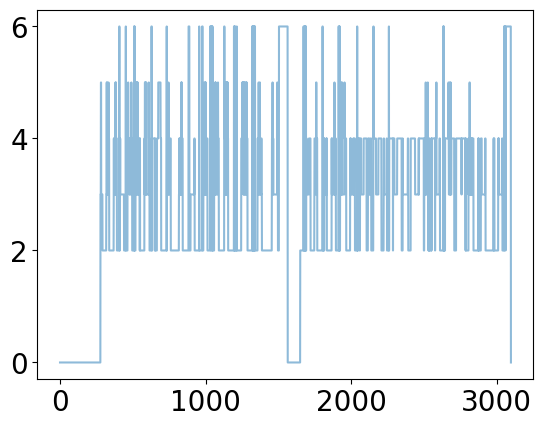

Exit predicted at frame 292 Pred: 3 -> 2)
Exit predicted at frame 338 Pred: 4 -> 2)
Exit predicted at frame 391 Pred: 4 -> 2)
Exit predicted at frame 440 Pred: 3 -> 2)
Exit predicted at frame 496 Pred: 4 -> 2)
Exit predicted at frame 548 Pred: 4 -> 2)
Exit predicted at frame 615 Pred: 4 -> 2)
Exit predicted at frame 652 Pred: 4 -> 2)
Exit predicted at frame 695 Pred: 4 -> 2)
Exit predicted at frame 761 Pred: 4 -> 2)
Exit predicted at frame 843 Pred: 4 -> 2)
Exit predicted at frame 925 Pred: 4 -> 2)
Exit predicted at frame 1013 Pred: 4 -> 2)
Exit predicted at frame 1091 Pred: 4 -> 2)
Exit predicted at frame 1155 Pred: 4 -> 2)
Exit predicted at frame 1288 Pred: 4 -> 2)
Exit predicted at frame 1387 Pred: 3 -> 2)
Exit predicted at frame 1497 Pred: 4 -> 2)
Exit predicted at frame 1650 Pred: 0 -> 2)
Exit predicted at frame 1721 Pred: 4 -> 2)
Exit predicted at frame 1767 Pred: 4 -> 2)
Exit predicted at frame 1833 Pred: 4 -> 2)
Exit predicted at frame 1895 Pred: 4 -> 2)
Exit predicted at frame

In [90]:


def vis_json_results(data_name = data_name, suffix = "nopostprocess_exp"):
    import matplotlib.pyplot as plt
    from organizer_module.postprocessor import PostProcessor
    import numpy as np

    # load from json
    with open(f'/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/output/previous/{data_name}_{suffix}.json', 'r') as f:
        data = json.load(f)
        results = data['results']
        gt_result_lst = data['gt_result_lst']

    print("DEBUG: results len: ", len(results))
    print("DEBUG: gt_result_lst len: ", len(gt_result_lst))

    # Apply Markov smoothing to the results
    # pp = PostProcessor()
    # pp.posture_records = results.copy()
    # # pp._markov_smoothing()
    # smoothed_results = pp.posture_records

    smoothed_results = results.copy()

    def compute_accuracy_presence(pred, gt):
        correct = 0
        total = 0
        for i in range(len(gt)):
            g = gt[i]
            p = pred[i]
            if g == -1:
                # do nothing
                continue
            elif g==0 and p == 0:
                correct += 1
            elif g in [1, 2, 3, 4, 5, 6]:
                if p in [2, 3, 4, 5, 6]:
                    correct += 1
            total += 1
        return correct / total

    def compute_accuracy(pred, gt):
        correct = 0
        total = 0
        for i in range(len(gt)):
            g = gt[i]
            p = pred[i]
            if g == -1:
                # do nothing
                continue
            elif g == 1:
                if p in [2, 3, 4, 5, 6]:
                    correct += 1
            elif p == g:
                    correct += 1
            total += 1
        return correct / total
    
    def compute_recall(pred, gt):
        # compute recall for each class
        recall_dict = {}
        for cls in [0, 2, 3, 4, 5, 6]:
            tp = sum([1 if p == cls and g == cls else 0 for p, g in zip(pred, gt)])
            fn = sum([1 if p != cls and g == cls else 0 for p, g in zip(pred, gt)])
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            recall_dict[cls] = recall
        return recall_dict
    
    def compute_precision(pred, gt):
        # compute precision for each class
        precision_dict = {}
        for cls in [0, 2, 3, 4, 5, 6]:
            tp = sum([1 if p == cls and g == cls else 0 for p, g in zip(pred, gt)])
            fp = sum([1 if p == cls and g != cls else 0 for p, g in zip(pred, gt)])
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            precision_dict[cls] = precision
        return precision_dict
    
    def compute_f1(pred, gt):
        recall_dict = compute_recall(pred, gt)
        precision_dict = compute_precision(pred, gt)
        f1_dict = {}
        for cls in [0, 2, 3, 4, 5, 6]:
            precision = precision_dict[cls]
            recall = recall_dict[cls]
            f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
            f1_dict[cls] = f1
        return f1_dict

    plt.plot(smoothed_results, alpha = 0.5)
    # plt.plot(results, alpha = 0.5)
    # plt.plot(gt_result_lst, alpha = 0.5)
    plt.show()
    # print(f"Accuracy before smoothing: {accuracy_before:.4f}")
    # print(f"Accuracy after smoothing: {accuracy_after:.4f}")

    # count the accuracy
    # when gt_results_lst is -1, we regard it as 0
    # when gt_results_lst is 1, it can match all the presence labels (2, 3, 4, 5, 6)
    # compute the accuracy
    correct = 0
    total = 0
    exits = []
    
    # results = [5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 2, 2]
    # exit prediction
    for i in range(10,len(results)-10):
        # if last 10 frames only have values within [3, 4, 5, 6]
        no2inPrev = True
        for idx in results[i-10:i]:
            if idx == 2:
                # print("found 2")
                no2inPrev = False
                break 
        
        if results[i] == 2 and no2inPrev:
            print(f"Exit predicted at frame {i} Pred: {results[i-1]} -> {results[i]})")
            exits.append(i)
        # if gt_result_lst[i-1] in [0, 1] and gt_result_lst[i] in [2, 3, 4, 5, 6]:
        #     print(f"Entry predicted at frame {i} (GT: {gt_result_lst[i-1]} -> {gt_result_lst[i]}, Pred: {results[i-1]} -> {results[i]})")
    return exits


    # disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Human', 'Standing', 'Sitting by Bed', 'Sitting on Bed', 'Lying w/o Cover', 'Lying with Cover'])
    # disp.plot(cmap=plt.cm.Blues)
    # # rotate x label by 45 degree
    # plt.xticks(rotation=45)
    # plt.title("Confusion Matrix for Posture Classification (Detailed)")
    # plt.show()

pred_exits = vis_json_results("case_study_hall_exit7", "cross_env")

In [91]:
# 7
exit_gt = [187, 237, 287, 335, 387, 434, 492, 543, 613, 692, 755, 838, 921, 1007, 1087, 1152, 1284, 1380, 1495, 1709, 1763, 1828, 1889, 1954, 2017, 2083, 2131, 2185, 2241, 2316, 2386, 2463, 2526, 2604, 2687, 2759, 2833, 2919, 3036]
def find_closest_exit(pred_exits, gt_exits):
    latency = []
    for gt in gt_exits:
        for pred in pred_exits:
            print("exit: ", pred, "gt: ", gt)
            if gt <= pred:
                print("found pair.")
                latency.append(gt - pred)
                break
    return latency
latency7 = find_closest_exit(pred_exits, exit_gt)
print(len(latency7))
print(len(exit_gt))
print("predicted exits:", len(pred_exits))
print("avg latency: ", sum(latency7)/len(latency7))


exit:  292 gt:  187
found pair.
exit:  292 gt:  237
found pair.
exit:  292 gt:  287
found pair.
exit:  292 gt:  335
exit:  338 gt:  335
found pair.
exit:  292 gt:  387
exit:  338 gt:  387
exit:  391 gt:  387
found pair.
exit:  292 gt:  434
exit:  338 gt:  434
exit:  391 gt:  434
exit:  440 gt:  434
found pair.
exit:  292 gt:  492
exit:  338 gt:  492
exit:  391 gt:  492
exit:  440 gt:  492
exit:  496 gt:  492
found pair.
exit:  292 gt:  543
exit:  338 gt:  543
exit:  391 gt:  543
exit:  440 gt:  543
exit:  496 gt:  543
exit:  548 gt:  543
found pair.
exit:  292 gt:  613
exit:  338 gt:  613
exit:  391 gt:  613
exit:  440 gt:  613
exit:  496 gt:  613
exit:  548 gt:  613
exit:  615 gt:  613
found pair.
exit:  292 gt:  692
exit:  338 gt:  692
exit:  391 gt:  692
exit:  440 gt:  692
exit:  496 gt:  692
exit:  548 gt:  692
exit:  615 gt:  692
exit:  652 gt:  692
exit:  695 gt:  692
found pair.
exit:  292 gt:  755
exit:  338 gt:  755
exit:  391 gt:  755
exit:  440 gt:  755
exit:  496 gt:  755


DEBUG: results len:  2212
DEBUG: gt_result_lst len:  2212


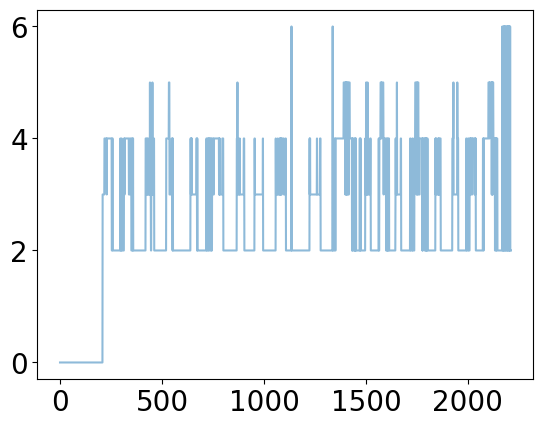

Exit predicted at frame 254 Pred: 4 -> 2)
Exit predicted at frame 350 Pred: 4 -> 2)
Exit predicted at frame 446 Pred: 3 -> 2)
Exit predicted at frame 462 Pred: 4 -> 2)
Exit predicted at frame 552 Pred: 4 -> 2)
Exit predicted at frame 672 Pred: 4 -> 2)
Exit predicted at frame 801 Pred: 4 -> 2)
Exit predicted at frame 904 Pred: 4 -> 2)
Exit predicted at frame 996 Pred: 4 -> 2)
Exit predicted at frame 1108 Pred: 4 -> 2)
Exit predicted at frame 1278 Pred: 4 -> 2)
Exit predicted at frame 1432 Pred: 4 -> 2)
Exit predicted at frame 1524 Pred: 4 -> 2)
Exit predicted at frame 1599 Pred: 4 -> 2)
Exit predicted at frame 1673 Pred: 4 -> 2)
Exit predicted at frame 1777 Pred: 4 -> 2)
Exit predicted at frame 1867 Pred: 4 -> 2)
Exit predicted at frame 1953 Pred: 4 -> 2)
Exit predicted at frame 2039 Pred: 4 -> 2)
Exit predicted at frame 2133 Pred: 4 -> 2)


In [92]:


def vis_json_results(data_name = data_name, suffix = "nopostprocess_exp"):
    import matplotlib.pyplot as plt
    from organizer_module.postprocessor import PostProcessor
    import numpy as np

    # load from json
    with open(f'/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/output/previous/{data_name}_{suffix}.json', 'r') as f:
        data = json.load(f)
        results = data['results']
        gt_result_lst = data['gt_result_lst']

    print("DEBUG: results len: ", len(results))
    print("DEBUG: gt_result_lst len: ", len(gt_result_lst))

    # Apply Markov smoothing to the results
    # pp = PostProcessor()
    # pp.posture_records = results.copy()
    # # pp._markov_smoothing()
    # smoothed_results = pp.posture_records

    smoothed_results = results.copy()

    def compute_accuracy_presence(pred, gt):
        correct = 0
        total = 0
        for i in range(len(gt)):
            g = gt[i]
            p = pred[i]
            if g == -1:
                # do nothing
                continue
            elif g==0 and p == 0:
                correct += 1
            elif g in [1, 2, 3, 4, 5, 6]:
                if p in [2, 3, 4, 5, 6]:
                    correct += 1
            total += 1
        return correct / total

    def compute_accuracy(pred, gt):
        correct = 0
        total = 0
        for i in range(len(gt)):
            g = gt[i]
            p = pred[i]
            if g == -1:
                # do nothing
                continue
            elif g == 1:
                if p in [2, 3, 4, 5, 6]:
                    correct += 1
            elif p == g:
                    correct += 1
            total += 1
        return correct / total
    
    def compute_recall(pred, gt):
        # compute recall for each class
        recall_dict = {}
        for cls in [0, 2, 3, 4, 5, 6]:
            tp = sum([1 if p == cls and g == cls else 0 for p, g in zip(pred, gt)])
            fn = sum([1 if p != cls and g == cls else 0 for p, g in zip(pred, gt)])
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            recall_dict[cls] = recall
        return recall_dict
    
    def compute_precision(pred, gt):
        # compute precision for each class
        precision_dict = {}
        for cls in [0, 2, 3, 4, 5, 6]:
            tp = sum([1 if p == cls and g == cls else 0 for p, g in zip(pred, gt)])
            fp = sum([1 if p == cls and g != cls else 0 for p, g in zip(pred, gt)])
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            precision_dict[cls] = precision
        return precision_dict
    
    def compute_f1(pred, gt):
        recall_dict = compute_recall(pred, gt)
        precision_dict = compute_precision(pred, gt)
        f1_dict = {}
        for cls in [0, 2, 3, 4, 5, 6]:
            precision = precision_dict[cls]
            recall = recall_dict[cls]
            f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
            f1_dict[cls] = f1
        return f1_dict

    plt.plot(smoothed_results, alpha = 0.5)
    # plt.plot(results, alpha = 0.5)
    # plt.plot(gt_result_lst, alpha = 0.5)
    plt.show()
    # print(f"Accuracy before smoothing: {accuracy_before:.4f}")
    # print(f"Accuracy after smoothing: {accuracy_after:.4f}")

    # count the accuracy
    # when gt_results_lst is -1, we regard it as 0
    # when gt_results_lst is 1, it can match all the presence labels (2, 3, 4, 5, 6)
    # compute the accuracy
    correct = 0
    total = 0
    exits = []
    
    # results = [5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 2, 2]
    # exit prediction
    for i in range(10,len(results)-10):
        # if last 10 frames only have values within [3, 4, 5, 6]
        no2inPrev = True
        for idx in results[i-10:i]:
            if idx == 2:
                # print("found 2")
                no2inPrev = False
                break 
        
        if results[i] == 2 and no2inPrev:
            print(f"Exit predicted at frame {i} Pred: {results[i-1]} -> {results[i]})")
            exits.append(i)
        # if gt_result_lst[i-1] in [0, 1] and gt_result_lst[i] in [2, 3, 4, 5, 6]:
        #     print(f"Entry predicted at frame {i} (GT: {gt_result_lst[i-1]} -> {gt_result_lst[i]}, Pred: {results[i-1]} -> {results[i]})")
    return exits


    # disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Human', 'Standing', 'Sitting by Bed', 'Sitting on Bed', 'Lying w/o Cover', 'Lying with Cover'])
    # disp.plot(cmap=plt.cm.Blues)
    # # rotate x label by 45 degree
    # plt.xticks(rotation=45)
    # plt.title("Confusion Matrix for Posture Classification (Detailed)")
    # plt.show()

pred_exits = vis_json_results("case_study_hall_exit8", "cross_env")

In [93]:
# 8
exit_gt = [238, 342, 457, 549, 670, 794, 900, 992, 1104, 1274, 1421, 1519, 1589, 1671, 1763, 1864, 1950, 2036, 2124]
def find_closest_exit(pred_exits, gt_exits):
    latency = []
    for gt in gt_exits:
        for pred in pred_exits:
            # print("exit: ", pred, "gt: ", gt)
            if gt - pred <= 0:
                # print("found pair.")
                latency.append(gt - pred)
                break
    return latency
latency8 = find_closest_exit(pred_exits, exit_gt)
latency8.extend(latency7)
print(latency8)
print(len(pred_exits))
print(len(exit_gt))

[-16, -8, -5, -3, -2, -7, -4, -4, -4, -4, -11, -5, -10, -2, -14, -3, -3, -3, -9, -105, -55, -5, -3, -4, -6, -4, -5, -2, -3, -6, -5, -4, -6, -4, -3, -4, -7, -2, -12, -4, -5, -6, -12, -9, -23, -7, -23, -5, -31, -6, -36, -5, -6, -21, -27, -7, -4, -3]
20
19


In [94]:
print(len(latency8))
latency8.sort()
print(latency8)
print("avg latency: ", sum(latency8[1:])/len(latency8[1:])/8)
# 62 exit events


58
[-105, -55, -36, -31, -27, -23, -23, -21, -16, -14, -12, -12, -11, -10, -9, -9, -8, -7, -7, -7, -7, -6, -6, -6, -6, -6, -6, -5, -5, -5, -5, -5, -5, -5, -5, -4, -4, -4, -4, -4, -4, -4, -4, -4, -4, -4, -3, -3, -3, -3, -3, -3, -3, -3, -2, -2, -2, -2]
avg latency:  -1.0899122807017543


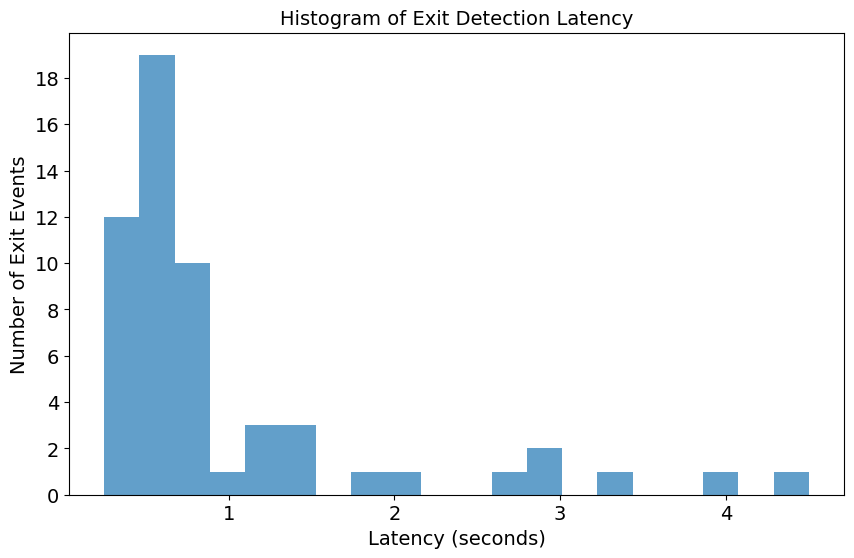

: 

In [ ]:
# plot histogram of average latency
import matplotlib.pyplot as plt
# figure size
plt.figure(figsize=(10, 6))
latency_all = [-lat/8 for lat in latency8]
plt.hist(latency_all[2:], bins=20, alpha=0.7)
plt.xlabel('Latency (seconds)', fontsize = 14)
plt.ylabel('Number of Exit Events', fontsize = 14)
plt.title('Histogram of Exit Detection Latency', fontsize = 14)
# set x, y axes text size and title text size
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# y ticks to show number of events
plt.yticks(range(0, 20, 2))
plt.savefig("exit_detection_latency_histogram.png")

# Summary of exit case study
total exit events: 58 
average time: -1.08 seconds

# Inference speed test

In [44]:
def test_inference(data_name=data_name, model_path = '/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/weights/all_current_data.pth', tag = "", k = None, corr = None):
    # use a data entry as test: /Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/data/hall5
    
    # 1. load the dataset ===============================================
    # dataset = ThermalDataset("/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/data/office1_0")
    dataset = ThermalDataset(f"/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/data/{data_name}", noCam = True)
    print(f"dataset {data_name}; length:", len(dataset))


    # 2. initialize our system's components ==================================
    #   2.1. heatsource detection module: load the module
    heat_detector = HeatSourceDetector()
    thermalinvariantpreprocessor = ThermalInvariantPreprocessor()
    #   2.1. posture detector module: load the model
    posture_detector_model = SimpleIRA_CNN()
    # load the pretrained weights for posture detection model
    posture_detector_model.load_state_dict(torch.load('/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/weights/all_current_data.pth'))
    #   2.2. kalman tracker module: load the module
    if k is not None:
        tracker = Tracker(k_thresh = k, temp_decrease_thresh = corr)
    else:
        tracker = Tracker()
    #   2.4. postprocessor module: load the module
    postprocessor = PostProcessor()

    import matplotlib.pyplot as plt
    from tqdm import tqdm
    

    # 3. loop through each fraome ========================================
    #   3.1. prepare the ground truth label list
    gt_result_lst = []
    waittime = 1
    visualization = True
    for idx in tqdm(range(0, len(dataset), 1)):
        # gt
        label = dataset.annotations_expanded[idx]
        gt_result_lst.append(label)

        # data
        ira_highres = dataset.get_ira_highres(idx)
        # make pixels less than 17 deg be 17 deg
        ira_highres[ira_highres < 18] = 18

        # plt.imshow(ira_highres)
        # plt.show()

        #   3.1. detect heat source
        thresh, mask = heat_detector.get_thresh_mask_otsu(ira_highres)
        
        mask_individual = heat_detector.process_frame_connected_components(ira_highres, min_size=100)

        #   3.2. detect presence with kalman tracker
        tracker.update_blobs(mask_individual, ira_highres, heat_detector.get_unmasked_mean(ira_highres, mask), idx)
        postprocessor.get_blobs(tracker.blobs, idx)

        #   3.3. posture detection if kalman shows presence; record it in postprocessor
        hasHuman = False
        for blob in tracker.blobs:
            if blob.is_residual == False: # if it is classified as human
                hasHuman = True

        hasHuman = True
        if hasHuman:
            # clip and normalize the ira_highres image, and convert to tensor before feeding into the posture detection model
            ira_highres = thermalinvariantpreprocessor(ira_highres)
            posture = posture_detector_model(torch.tensor(ira_highres, dtype=torch.float32).unsqueeze(0)) # add batch and channel dimension
            posture_label = torch.argmax(posture, dim=1).item()
            # print("DEBUG: posture label: ", posture_label)
            posture_label = inverse_remap_labels_simple(posture_label)  # remap the posture label
            # print("DEBUG: inverse remap posture label: ", posture_label)
            postprocessor.get_posture(posture_label, idx)  # inverse remap the posture label
            posture_str = label_to_text_simple(posture_label)
        else:
            posture_label = 0
            posture_str = label_to_text_simple(posture_label)
            postprocessor.get_posture(0, idx)

        # visualize the result for this frame
        # if visualization:
        #     visualize_frame(ira_highres, tracker.blobs, posture_str, idx, 10)
    
    # 4. save the results to /Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/output/{data_name}.json
    with open(f'/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/output/previous/{data_name}_{tag}.json', 'w') as f:
        json.dump({'results': postprocessor.posture_records, 'gt_result_lst': gt_result_lst}, f, indent=4)

    # draw the confusion matrix for posture classificatino result
    # confusion_matrix_draw(postprocessor.posture_records, gt_result_lst)

def confusion_matrix_draw(results, gt_result_lst):
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

    y_true = gt_result_lst
    y_pred = [1 if r[1] == 'HUMAN' else 0 for r in results]

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Human', 'Human'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix for Posture Classification")
    plt.show()

# results = postprocessor.posture_records
# # write results and gt_result_lst to a json file for later analysis
# with open(f'/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/output/{data_name}.json', 'w') as f:
#     json.dump({'results': results, 'gt_result_lst': gt_result_lst}, f, indent=4)

def pipeline_gridsearch():
    # load yaml content from /Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/config/exp_setup.yaml
    with open('/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/config/exp_setup.yaml', 'r') as f:
        config = yaml.safe_load(f)
        train_all = config['train_all'][:3]
    TEMP_DECREASE_THRESH = [-0.9, -0.92, -0.95]
    K_THRESH = [0.003, 0.004, 0.005]

    for temp_thresh in TEMP_DECREASE_THRESH:
        for k_thresh in K_THRESH:
            pred = []
            gt = []
            print(f"Testing with TEMP_DECREASE_THRESH: {temp_thresh}, K_THRESH: {k_thresh}")
            for folder in train_all:
                gt_result_lst, pred_res_lst = pipeline_gridsearch(folder)
                pred.extend(pred_res_lst)
                gt.extend(gt_result_lst)
                print("accuracy: ", sum([1 if p == 1 and g == 1 else 0 for p, g in zip(pred_res_lst, gt_result_lst)]) / len(gt_result_lst))
                print("present predicted as absent: ", sum([1 if p == 0 and g == 1 else 0 for p, g in zip(pred_res_lst, gt_result_lst)]) / len(gt_result_lst))
                plt.plot(pred_res_lst, alpha = 0.5, label = "pred")
                plt.plot(gt_result_lst, alpha = 0.5, label = "GT")
                plt.legend()
                plt.show()
                print("absent predicted as present: ", sum([1 if p == 1 and g == 0 else 0 for p, g in zip(pred_res_lst, gt_result_lst)]) / len(gt_result_lst)) 
            print("===summary: present predicted as absent: ", sum([1 if p == 0 and g == 1 else 0 for p, g in zip(pred, gt)]) / len(gt))
            print("===summary: absent predicted as present: ", sum([1 if p == 1 and g == 0 else 0 for p, g in zip(pred, gt)]) / len(gt))
            print("=== summary: accuracy: ", sum([1 if p == 1 and g == 1 else 0 for p, g in zip(pred, gt)]) / len(gt)) 


def vis_json_results(data_name = data_name, suffix = "nopostprocess_exp"):
    import matplotlib.pyplot as plt
    from organizer_module.postprocessor import PostProcessor
    import numpy as np

    # load from json
    with open(f'/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/output/previous/{data_name}_{suffix}.json', 'r') as f:
        data = json.load(f)
        results = data['results']
        gt_result_lst = data['gt_result_lst']

    print("DEBUG: results len: ", len(results))
    print("DEBUG: gt_result_lst len: ", len(gt_result_lst))

    # Apply Markov smoothing to the results
    # pp = PostProcessor()
    # pp.posture_records = results.copy()
    # # pp._markov_smoothing()
    # smoothed_results = pp.posture_records

    smoothed_results = results.copy()

    def compute_accuracy_presence(pred, gt):
        correct = 0
        total = 0
        for i in range(len(gt)):
            g = gt[i]
            p = pred[i]
            if g == -1:
                # do nothing
                continue
            elif g==0 and p == 0:
                correct += 1
            elif g in [1, 2, 3, 4, 5, 6]:
                if p in [2, 3, 4, 5, 6]:
                    correct += 1
            total += 1
        return correct / total

    def compute_accuracy(pred, gt):
        correct = 0
        total = 0
        for i in range(len(gt)):
            g = gt[i]
            p = pred[i]
            if g == -1:
                # do nothing
                continue
            elif g == 1:
                if p in [2, 3, 4, 5, 6]:
                    correct += 1
            elif p == g:
                    correct += 1
            total += 1
        return correct / total
    
    def compute_recall(pred, gt):
        # compute recall for each class
        recall_dict = {}
        for cls in [0, 2, 3, 4, 5, 6]:
            tp = sum([1 if p == cls and g == cls else 0 for p, g in zip(pred, gt)])
            fn = sum([1 if p != cls and g == cls else 0 for p, g in zip(pred, gt)])
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            recall_dict[cls] = recall
        return recall_dict
    
    def compute_precision(pred, gt):
        # compute precision for each class
        precision_dict = {}
        for cls in [0, 2, 3, 4, 5, 6]:
            tp = sum([1 if p == cls and g == cls else 0 for p, g in zip(pred, gt)])
            fp = sum([1 if p == cls and g != cls else 0 for p, g in zip(pred, gt)])
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            precision_dict[cls] = precision
        return precision_dict
    
    def compute_f1(pred, gt):
        recall_dict = compute_recall(pred, gt)
        precision_dict = compute_precision(pred, gt)
        f1_dict = {}
        for cls in [0, 2, 3, 4, 5, 6]:
            precision = precision_dict[cls]
            recall = recall_dict[cls]
            f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
            f1_dict[cls] = f1
        return f1_dict

    accuracy_before = compute_accuracy(results, gt_result_lst)
    recall_before = compute_recall(results, gt_result_lst)
    precision_before = compute_precision(results, gt_result_lst)
    f1_before = compute_f1(results, gt_result_lst)
    # accuracy_after = compute_accuracy(smoothed_results, gt_result_lst)
    print("accuracy of presence: ", compute_accuracy_presence(results, gt_result_lst))
    print("accuracy of all poses: ", accuracy_before)
    
    print("recall of all poses: ", recall_before)

    plt.plot(smoothed_results, alpha = 0.5)
    # plt.plot(results, alpha = 0.5)
    plt.plot(gt_result_lst, alpha = 0.5)
    plt.show()
    # print(f"Accuracy before smoothing: {accuracy_before:.4f}")
    # print(f"Accuracy after smoothing: {accuracy_after:.4f}")

    # count the accuracy
    # when gt_results_lst is -1, we regard it as 0
    # when gt_results_lst is 1, it can match all the presence labels (2, 3, 4, 5, 6)
    # compute the accuracy
    correct = 0
    total = 0
    for i in range(len(gt_result_lst)):
        gt = gt_result_lst[i]
        pred = results[i]
        if gt == -1:
            gt = 0
        if gt == 1:
            if pred in [2, 3, 4, 5, 6]:
                correct += 1
        else:
            if pred == gt:
                correct += 1
        total += 1
    accuracy = correct / total
    print(f"Posture accuracy: {accuracy:.4f}")

    # results = [5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 2, 2]
    # exit prediction
    for i in range(10,len(results)-10):
        # if last 10 frames only have values within [3, 4, 5, 6]
        no2inPrev = True
        for idx in results[i-10:i]:
            if idx == 2:
                # print("found 2")
                no2inPrev = False
                break 
        
        if results[i] == 2 and no2inPrev:
            print(f"Exit predicted at frame {i} Pred: {results[i-1]} -> {results[i]})")
            
        # if gt_result_lst[i-1] in [0, 1] and gt_result_lst[i] in [2, 3, 4, 5, 6]:
        #     print(f"Entry predicted at frame {i} (GT: {gt_result_lst[i-1]} -> {gt_result_lst[i]}, Pred: {results[i-1]} -> {results[i]})")

    # plot confusion matrix
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    # presence classification confusion matrix
    y_true = [1 if r in [2, 3, 4, 5, 6] else 0 for r in gt_result_lst]
    y_pred = [1 if r in [2, 3, 4, 5, 6] else 0 for r in results]
    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix for Presence Classification:", cm)

    # disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Human', 'Human'])
    # disp.plot(cmap=plt.cm.Blues)
    # plt.title("Confusion Matrix for Presence Classification (Binary)")
    # plt.show()

    # plot posture classification confusion matrix
    # remove ambiguous labels in gt_result_lst and results
    y_true = [r for r in gt_result_lst if r != -1 and r != 1]
    y_pred = [results[i] for i in range(len(results)) if gt_result_lst[i] != -1 and gt_result_lst[i] != 1]
    cm = confusion_matrix(y_true, y_pred, labels=[0, 2, 3, 4, 5, 6])
    print("Confusion Matrix for Posture Classification (Detailed):", cm)

    # disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Human', 'Standing', 'Sitting by Bed', 'Sitting on Bed', 'Lying w/o Cover', 'Lying with Cover'])
    # disp.plot(cmap=plt.cm.Blues)
    # # rotate x label by 45 degree
    # plt.xticks(rotation=45)
    # plt.title("Confusion Matrix for Posture Classification (Detailed)")
    # plt.show()
def vis_results(data_name = "office0_4", tag = ""):
    # visualize the results in /Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/output/{data_name}_nopostprocess_exp.json
    # data_name = "home01"
    vis_json_results(data_name, tag)

def test_users_inenv():
    # test the model across different users
    model_path = "/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/weights/posture_cnn_all_full.pth"
    test_env = ['office0_4', 'home01', 'home2', 'home31']
    test_env = ['office0_4']

    # load the model
    for e in test_env:
        test_inference(model_path = model_path, data_name = e)

def test_users_crossenv():
    # test the model across different users and environments
    test_env = ['hall5', 'office1_0', 'office2_0']
    test_env_ids = ['env0', 'env5', 'env6']
    for env, env_id in zip(test_env, test_env_ids):
        model_path = f"/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/weights/posture_cnn_{env_id}.pth"
        test_inference(model_path = model_path, data_name = env)




dataset office0_sf_0; length: 2691


100%|██████████| 2691/2691 [00:12<00:00, 213.87it/s]

Inference time for office0_sf_0: 12.63 seconds
DEBUG: results len:  2691
DEBUG: gt_result_lst len:  2691
accuracy of presence:  0.7695980899323518
accuracy of all poses:  0.7688022284122563
recall of all poses:  {0: 0.0, 2: 1.0, 3: 1.0, 4: 0.9957894736842106, 5: 1.0, 6: 1.0}


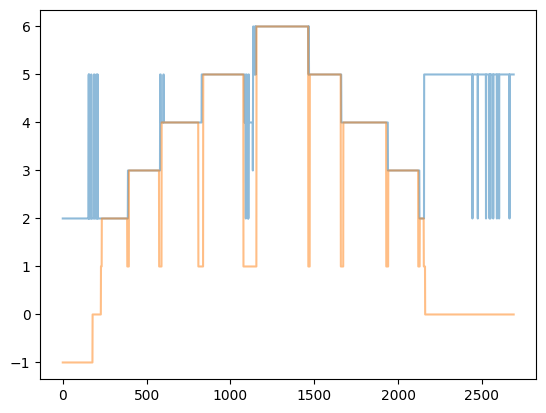

Posture accuracy: 0.7179
Exit predicted at frame 1092 Pred: 4 -> 2)
Exit predicted at frame 1105 Pred: 4 -> 2)
Exit predicted at frame 2128 Pred: 3 -> 2)
Exit predicted at frame 2444 Pred: 5 -> 2)
Exit predicted at frame 2476 Pred: 5 -> 2)
Exit predicted at frame 2525 Pred: 5 -> 2)
Exit predicted at frame 2546 Pred: 5 -> 2)
Exit predicted at frame 2568 Pred: 5 -> 2)
Exit predicted at frame 2590 Pred: 5 -> 2)
Exit predicted at frame 2603 Pred: 5 -> 2)
Exit predicted at frame 2665 Pred: 5 -> 2)
Confusion Matrix for Presence Classification: [[   0  947]
 [   0 1744]]
Confusion Matrix for Posture Classification (Detailed): [[  0  51   0   0 528   0]
 [  0 176   0   0   0   0]
 [  0   0 359   0   0   0]
 [  0   0   0 473   2   0]
 [  0   0   0   0 425   0]
 [  0   0   0   0   0 309]]


In [34]:
# test_results()
# test_postprocessor()
import time

if __name__ == "__main__":
    # office0_4: 0.9919028340080972 len 12274
    # hall5: 0.9850 len 2394
    # office0_1: 0.9964912280701754, len 2963
    # office0_2: 0.9953646275380297, len 15525
    # office1_0: 0.9964, len 5433
    # office2_0: 0.9913, len 6004
    # home01: 
    env = "office0_sf_0"
    model = "posture_cnn_cross_user_user5"
    tag = "cross_user"
    # tag = "nopostprocess_exp"
    k = 0.005
    corr = -0.75
    t_start = time.time()
    test_inference(env, model_path=f'/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/weights/weights_final/{model}_0417.pth', tag = 'cross_user', k = k, corr = corr)
    t_end = time.time()
    print(f"Inference time for {env}: {t_end - t_start:.2f} seconds")
    vis_results(env, tag)
    # pipeline_gridsearch()
    # test_users_inenv()
    # test_users_crossenv()
    # saved here: /Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/output/previous/office0_sf_0_cross_user.json

In [ ]:
# test_results()
# test_postprocessor()
import time

if __name__ == "__main__":
    # office0_4: 0.9919028340080972 len 12274
    # hall5: 0.9850 len 2394
    # office0_1: 0.9964912280701754, len 2963
    # office0_2: 0.9953646275380297, len 15525
    # office1_0: 0.9964, len 5433
    # office2_0: 0.9913, len 6004
    # home01: 
    env = "sleep_casestudy"
    model = "posture_cnn_cross_user_user5"
    tag = "sleep_casestudy"
    # tag = "nopostprocess_exp"
    k = 0.005
    corr = -0.75
    t_start = time.time()
    test_inference(env, model_path=f'/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/weights/weights_final/{model}_0417.pth', tag = 'cross_user', k = k, corr = corr)
    t_end = time.time()
    print(f"Inference time for {env}: {t_end - t_start:.2f} seconds")
    # vis_results(env, tag)
    # pipeline_gridsearch()
    # test_users_inenv()
    # test_users_crossenv()
    # saved here: /Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/output/previous/office0_sf_0_cross_user.json

dataset sleep_casestudy; length: 45


100%|██████████| 45/45 [00:01<00:00, 37.12it/s]

Inference time for sleep_casestudy: 1.27 seconds


: 